# Experiment 1.3: Statistical Analysis

This notebook performs a **rigorous multi-method statistical comparison** of all tabular learning
algorithms evaluated in Experiment 1, following the methodology established in the ML benchmarking
literature (Demsar 2006; Garcia & Herrera 2008; Benavoli et al. 2016).

---

## What this notebook answers

| Question | Answered by |
|----------|-------------|
| Is there *any* real performance difference across all methods? | Friedman + Iman-Davenport omnibus test |
| Which *specific* pairs of methods differ significantly? | Nemenyi CD diagram · Wilcoxon + Holm |
| *How large* are those differences in practice? | Vargha-Delaney A effect sizes |
| Which method dominates head-to-head across datasets? | Win/Loss matrix |
| Which method *wins outright* most individual folds? | PAMA |
| How stable / uncertain are the rankings? | Bootstrap confidence intervals |

> **Foundation models** (TabPFN, TabPFN v2, MITRA, TabICL, etc.) are highlighted in **red** throughout all figures.

---

## Why rank-based tests?

Performance values vary wildly across datasets (AUC of 0.65 on one dataset, 0.95 on another).
Directly averaging those numbers conflates dataset difficulty with method quality.
Ranking methods *within each dataset* first puts all datasets on the same scale:
rank 1 = best on that dataset, regardless of the absolute level.

All hypothesis tests here operate on these ranks — the gold standard for
multi-dataset algorithm comparison (Demsar 2006).

---

## Table of Contents

### Part 0 — Setup
- 1. Imports & Paths
- 2. Data Loading
- 3. Statistical Helper Functions
- 4. Analysis Pipeline Function

### Part 1 — PD (Probability of Default) · Metric: AUC ↑
- A. Descriptive statistics & average ranks
- B. Friedman omnibus test — are there ANY differences?
- C. Nemenyi post-hoc — Critical Difference diagram
- D. Wilcoxon + Holm post-hoc — which specific pairs differ?
- E. Effect sizes — Vargha-Delaney A
- F. Win/Loss matrix (draws = 0.5 each)
- G. PAMA — fold-level win rates
- H. Rank distributions & Bootstrap CIs

### Part 2 — LGD (Loss Given Default) · Metric: R² ↑
- Same structure as Part 1 (note: only N = 7 datasets → lower power)

### Part 3 — Summary & Interpretation Guide

---

## Statistical Tests at a Glance

| Step | Test | Input | Key output |
|------|------|-------|------------|
| **B** | Friedman + Iman-Davenport | N×k rank matrix | Single p-value: proceed or stop |
| **C** | Nemenyi / CD diagram | Average ranks | Groups of statistically indistinguishable methods |
| **D** | Wilcoxon + Holm | Raw performance values per dataset | Significant pairs at α = 0.05 |
| **E** | Vargha-Delaney A | Raw performance values | Effect size per pair in [0, 1] |
| **F** | Win/Loss | Raw performance values | Head-to-head dataset counts |
| **G** | PAMA | Fold-level values | % of folds each method wins outright |
| **H** | Bootstrap CIs | Rank matrix | 95% CI on average rank via resampling |

---

## References

- **Demsar (2006)** — *Statistical comparisons of classifiers over multiple data sets.* JMLR 7.
- **Garcia & Herrera (2008)** — *An extension on "Statistical comparisons of classifiers."* JMLR 9.
- **Vargha & Delaney (2000)** — *A critique and improvement of the CL common language effect size.* JRSS-A.
- **Delgado et al. (2014)** — *Do we need hundreds of classifiers to solve real world classification problems?* JMLR 15.
- **Benavoli et al. (2016)** — *Should we really use post-hoc tests based on mean-ranks?* JMLR 17.

## 1. Imports & Paths

Standard scientific Python stack. Key additions beyond numpy/pandas/matplotlib:
- `scipy.stats.friedmanchisquare`, `wilcoxon` — rank-based hypothesis tests
- `scipy.stats.f`, `chi2` — distributions for the Iman-Davenport F-correction
- `statsmodels.stats.multitest.multipletests` — Holm step-down correction for multiple comparisons
- `scipy.stats.rankdata` — used inside the Vargha-Delaney A computation

In [36]:
# Standard imports
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import friedmanchisquare, wilcoxon, rankdata, chi2, mannwhitneyu
from scipy.stats import f as f_dist
from itertools import combinations
from statsmodels.stats.multitest import multipletests
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm
import math

# Setup paths
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.methods.method_config import FOUNDATION_METHODS

EXPERIMENT_NAME = "experiment1"
RESULTS_DIR = PROJECT_ROOT / "results" / EXPERIMENT_NAME
SUMMARY_DIR = RESULTS_DIR / "summary"
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 80)
print("  EXPERIMENT 1.3: STATISTICAL ANALYSIS")
print("  Following Demsar (2006), Garcia & Herrera (2008)")
print("=" * 80)
print(f"Project root:  {PROJECT_ROOT}")
print(f"Results dir:   {RESULTS_DIR}")
print(f"Figures dir:   {FIGURES_DIR}")

# Generate summaries if needed
if SUMMARY_DIR.exists() and any(SUMMARY_DIR.glob("*.csv")):
    print("\nSummary files present.")
else:
    print("\nGenerating summaries...")
    from src.utils.summarize_results import summarize_results
    summarize_results(experiment=EXPERIMENT_NAME)

print("\nSetup complete.")

  EXPERIMENT 1.3: STATISTICAL ANALYSIS
  Following Demsar (2006), Garcia & Herrera (2008)
Project root:  c:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit
Results dir:   c:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results\experiment1
Figures dir:   c:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results\experiment1\figures

Summary files present.

Setup complete.


In [37]:
# =============================================================================
# FONT & STYLE CONFIGURATION
# =============================================================================
FONT_SCALE = 1.5

plt.rcParams['figure.figsize'] = (20, 10)
plt.rcParams['figure.dpi'] = 96
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['font.size'] = FONT_SCALE * 11
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.titlesize'] = FONT_SCALE * 15
plt.rcParams['axes.labelsize'] = FONT_SCALE * 12
plt.rcParams['xtick.labelsize'] = FONT_SCALE * 12
plt.rcParams['ytick.labelsize'] = FONT_SCALE * 10
sns.set_style('whitegrid')
sns.set_palette('Set2')

FS_TITLE = FONT_SCALE * 16
FS_SUBTITLE = FONT_SCALE * 14
FS_AXIS_LABEL = FONT_SCALE * 12
FS_TICK = FONT_SCALE * 9
FS_TICK_Y = FONT_SCALE * 10
FS_ANNOT = FONT_SCALE * 7
FS_LEGEND = FONT_SCALE * 10
FS_BAR_LABEL = FONT_SCALE * 9
FS_SUPTITLE = FONT_SCALE * 16

## 2. Data Loading

We load the **raw fold-level results** produced by `src/utils/summarize_results.py`.
Each row in the raw CSV is one `(method, dataset, fold_id, hpo_mode)` observation.

**For most statistical tests** the 5 folds are averaged per dataset first, giving a single
performance score per `(method, dataset)` pair — this is the N × k performance matrix
that feeds all hypothesis tests.  Treating each fold as an independent observation would
inflate N and produce anti-conservative (overconfident) p-values, because folds from the
same dataset are correlated (Demsar 2006).

**PAMA (Section G)** is the exception: it uses the raw fold-level observations to get
finer-grained win counts across N × 5 = 75 (PD) or 35 (LGD) observations.

In [38]:
pd_raw = pd.read_csv(SUMMARY_DIR / "summary_pd_raw.csv")
lgd_raw = pd.read_csv(SUMMARY_DIR / "summary_lgd_raw.csv")

print("Data loaded:")
print(f"  PD:  {len(pd_raw)} fold-results, {pd_raw['method'].nunique()} methods, {pd_raw['dataset'].nunique()} datasets")
print(f"  LGD: {len(lgd_raw)} fold-results, {lgd_raw['method'].nunique()} methods, {lgd_raw['dataset'].nunique()} datasets")
print(f"  PD methods:  {sorted(pd_raw['method'].unique())}")
print(f"  LGD methods: {sorted(lgd_raw['method'].unique())}")

Data loaded:
  PD:  4350 fold-results, 29 methods, 15 datasets
  LGD: 1540 fold-results, 22 methods, 7 datasets
  PD methods:  ['LogReg', 'NCM', 'NaiveBayes', 'RandomForest', 'amformer', 'autoint', 'catboost', 'danets', 'dcn2', 'excelformer', 'ftt', 'knn', 'lightgbm', 'mitra', 'mlp', 'mlp_plr', 'realmlp', 'snn', 'svm', 'switchtab', 't2gformer', 'tabicl', 'tabm', 'tabnet', 'tabpfn', 'tabpfn_real', 'tabpfn_v2', 'tangos', 'xgboost']
  LGD methods: ['LinearRegression', 'RandomForest', 'autoint', 'catboost', 'dcn2', 'excelformer', 'ftt', 'knn', 'lightgbm', 'mlp', 'mlp_plr', 'modernNCA', 'ptarl', 'realmlp', 'resnet', 'svm', 't2gformer', 'tabm', 'tabnet', 'tabpfn_v2', 'tangos', 'xgboost']


## 3. Statistical Helper Functions

The cell below defines all building blocks used by the main analysis pipeline.
Plain-language summary:

| Function | What it does |
|----------|-------------|
| `compute_dataset_performance` | Average 5-fold scores → N × k performance matrix |
| `compute_foldlevel_performance` | Keep fold scores → (N·5) × k matrix (for PAMA only) |
| `compute_ranks` | Rank methods within each dataset row (1 = best) |
| `friedman_iman_davenport` | Omnibus test: any difference among k methods at all? |
| `nemenyi_cd` | Compute the Critical Difference threshold from Demsar Table 5 |
| `pairwise_wilcoxon_holm` | All pairwise signed-rank tests + Holm step-down correction |
| `vargha_delaney_a` | P(method A scores higher than method B) |
| `compute_all_effect_sizes` | Apply VD-A to every method pair |
| `compute_win_loss` | Head-to-head wins/losses (draws split as 0.5 to each side) |
| `compute_pama` | Fraction of observations each method achieves the top score |
| `bootstrap_rank_ci` | 95% CI on average rank via 10,000 bootstrap resamples |

Visualization functions (`plot_cd_diagram`, `plot_significance_heatmap`, etc.) follow
in the same cell.

In [39]:
# =============================================================================
# STATISTICAL ANALYSIS FUNCTIONS
# Following Demsar (2006), Garcia & Herrera (2008), Benavoli et al. (2016)
# =============================================================================

# ---------------------------------------------------------------------------
# 1. Data preparation
# ---------------------------------------------------------------------------

def compute_dataset_performance(raw_df, metric, hpo_mode='HPO'):
    """Dataset x method matrix: mean performance across 5 CV folds per dataset."""
    df = raw_df[raw_df['hpo_mode'] == hpo_mode].copy()
    if metric not in df.columns:
        return None
    pivot = df.pivot_table(index='dataset', columns='method', values=metric, aggfunc='mean')
    return pivot.dropna(axis=1)


def compute_foldlevel_performance(raw_df, metric, hpo_mode='HPO'):
    """(Dataset x fold) x method matrix for fold-level analyses (PAMA)."""
    df = raw_df[raw_df['hpo_mode'] == hpo_mode].copy()
    if metric not in df.columns:
        return None
    pivot = df.pivot_table(index=['dataset', 'fold_id'], columns='method', values=metric)
    return pivot.dropna(axis=1)


def compute_ranks(perf_matrix, higher_is_better=True):
    """Rank methods per row. 1 = best."""
    return perf_matrix.rank(axis=1, ascending=not higher_is_better, method='average')


# ---------------------------------------------------------------------------
# 2. Friedman + Iman-Davenport (Demsar 2006, Sec 3.2)
# ---------------------------------------------------------------------------

def friedman_iman_davenport(perf_matrix, higher_is_better=True):
    """
    Friedman test with Iman-Davenport correction.

    The original Friedman statistic (chi2_F) is conservative. The Iman-Davenport
    correction (F_F) follows an F-distribution and has better power.

    Returns: (chi2_F, F_F, p_friedman, p_iman_davenport, N, k)
    """
    ranks = compute_ranks(perf_matrix, higher_is_better)
    N = ranks.shape[0]  # number of datasets
    k = ranks.shape[1]  # number of methods
    avg_ranks = ranks.mean(axis=0)

    # Friedman statistic (Eq. 1 in Demsar)
    chi2_F = (12 * N / (k * (k + 1))) * (
        (avg_ranks ** 2).sum() - k * (k + 1) ** 2 / 4
    )
    # Iman-Davenport correction (Eq. 2 in Demsar)
    F_F = ((N - 1) * chi2_F) / (N * (k - 1) - chi2_F)
    p_friedman = 1 - chi2.cdf(chi2_F, k - 1)
    p_iman = 1 - f_dist.cdf(F_F, k - 1, (k - 1) * (N - 1))
    return chi2_F, F_F, p_friedman, p_iman, N, k


# ---------------------------------------------------------------------------
# 3. Nemenyi Critical Difference (Demsar 2006, Eq. 7)
# ---------------------------------------------------------------------------

# Critical values q_alpha for the Studentized range statistic / sqrt(2)
# From Demsar (2006), Table 5, alpha=0.05
Q_ALPHA_005 = {
    2: 1.960, 3: 2.344, 4: 2.569, 5: 2.728,
    6: 2.850, 7: 2.949, 8: 3.031, 9: 3.102,
    10: 3.164, 11: 3.219, 12: 3.268, 13: 3.313,
    14: 3.354, 15: 3.391, 16: 3.426, 17: 3.458,
    18: 3.489, 19: 3.517, 20: 3.544, 21: 3.569,
    22: 3.593, 23: 3.616, 24: 3.637, 25: 3.658,
    26: 3.678, 27: 3.696, 28: 3.714, 29: 3.732,
    30: 3.749,
}
# alpha=0.10
Q_ALPHA_010 = {
    2: 1.645, 3: 2.052, 4: 2.291, 5: 2.460,
    6: 2.589, 7: 2.693, 8: 2.780, 9: 2.855,
    10: 2.920, 11: 2.978, 12: 3.030, 13: 3.077,
    14: 3.120, 15: 3.159, 16: 3.196, 17: 3.230,
    18: 3.261, 19: 3.291, 20: 3.319, 21: 3.345,
    22: 3.370, 23: 3.394, 24: 3.416, 25: 3.437,
    26: 3.457, 27: 3.476, 28: 3.495, 29: 3.513,
    30: 3.530,
}

def nemenyi_cd(k, N, alpha=0.05):
    """CD = q_alpha * sqrt(k(k+1) / (6N))"""
    table = Q_ALPHA_005 if alpha == 0.05 else Q_ALPHA_010
    if k in table:
        q = table[k]
    else:
        from scipy.stats import norm
        q = norm.ppf(1 - alpha / (k * (k - 1)))
    return q * np.sqrt(k * (k + 1) / (6 * N))


# ---------------------------------------------------------------------------
# 4. Pairwise Wilcoxon signed-rank + Holm (Demsar 2006, Sec 3.3)
# ---------------------------------------------------------------------------

def pairwise_wilcoxon_holm(perf_matrix):
    """
    Pairwise Wilcoxon signed-rank tests with Holm step-down correction.
    More powerful than Nemenyi because it uses actual performance values,
    not just ranks, and Holm is uniformly more powerful than Bonferroni.
    """
    methods = list(perf_matrix.columns)
    results = []
    for ma, mb in combinations(methods, 2):
        diff = perf_matrix[ma] - perf_matrix[mb]
        if (diff == 0).all():
            results.append({'method_a': ma, 'method_b': mb, 'stat': np.nan, 'p_raw': 1.0})
            continue
        try:
            stat, p_raw = wilcoxon(perf_matrix[ma], perf_matrix[mb],
                                   alternative='two-sided', zero_method='wilcox')
        except ValueError:
            results.append({'method_a': ma, 'method_b': mb, 'stat': np.nan, 'p_raw': 1.0})
            continue
        results.append({'method_a': ma, 'method_b': mb, 'stat': stat, 'p_raw': p_raw})

    if not results:
        return pd.DataFrame()
    res_df = pd.DataFrame(results)
    reject, p_corrected, _, _ = multipletests(res_df['p_raw'], alpha=0.05, method='holm')
    res_df['p_corrected'] = p_corrected
    res_df['significant'] = reject
    return res_df


# ---------------------------------------------------------------------------
# 5. Effect sizes: Vargha-Delaney A & Cliff's delta
# ---------------------------------------------------------------------------

def vargha_delaney_a(x, y):
    """
    Vargha-Delaney A measure (A12): probability that a random observation
    from x is larger than a random observation from y.
    A = 0.5 means no effect. A > 0.5 means x tends to be larger.
    """
    nx, ny = len(x), len(y)
    r = rankdata(np.concatenate([x, y]))
    r1 = r[:nx].sum()
    return (r1 / nx - (nx + 1) / 2) / ny


def cliffs_delta(x, y):
    """Cliff's delta = 2A - 1. Ranges from -1 to +1."""
    return 2 * vargha_delaney_a(x, y) - 1


def a_effect_label(a_val):
    """Effect size label based on Vargha & Delaney (2000) thresholds."""
    d = abs(a_val - 0.5)
    if d < 0.06:
        return 'negligible'
    elif d < 0.14:
        return 'small'
    elif d < 0.21:
        return 'medium'
    else:
        return 'large'


def compute_all_effect_sizes(perf_matrix):
    """Compute pairwise Vargha-Delaney A for all method pairs."""
    methods = list(perf_matrix.columns)
    results = []
    for ma, mb in combinations(methods, 2):
        a_val = vargha_delaney_a(perf_matrix[ma].values, perf_matrix[mb].values)
        delta = 2 * a_val - 1
        results.append({
            'method_a': ma, 'method_b': mb,
            'A': a_val, 'cliffs_delta': delta,
            'effect': a_effect_label(a_val)
        })
    return pd.DataFrame(results)


# ---------------------------------------------------------------------------
# 6. Win / Draw / Loss
# ---------------------------------------------------------------------------

def compute_win_loss(perf_matrix, tolerance=1e-6):
    """
    For each pair (A, B), count datasets where A > B (win) or A < B (loss).
    Draws (|diff| <= tolerance) contribute 0.5 to BOTH wins and losses,
    so wins + losses = N for every pair — no information is discarded.

    Example: out of 15 datasets, A wins 10, draws 2, loses 3 →
      wins = 10 + 0.5*2 = 11.0,  losses = 3 + 0.5*2 = 4.0  → shown as 11/4
    """
    methods = list(perf_matrix.columns)
    results = []
    for ma, mb in combinations(methods, 2):
        diff = perf_matrix[ma] - perf_matrix[mb]
        n_wins   = (diff > tolerance).sum()
        n_losses = (diff < -tolerance).sum()
        n_draws  = len(diff) - n_wins - n_losses
        results.append({
            'method_a': ma, 'method_b': mb,
            'wins'  : n_wins   + 0.5 * n_draws,
            'losses': n_losses + 0.5 * n_draws,
        })
    return pd.DataFrame(results)


# ---------------------------------------------------------------------------
# 7. PAMA (Delgado et al. 2014)
# ---------------------------------------------------------------------------

def compute_pama(perf_matrix, higher_is_better=True):
    """PAMA: fraction of observations where each method achieves the best score."""
    if higher_is_better:
        best = perf_matrix.idxmax(axis=1)
    else:
        best = perf_matrix.idxmin(axis=1)
    counts = best.value_counts()
    for m in perf_matrix.columns:
        if m not in counts.index:
            counts[m] = 0
    return (counts / len(perf_matrix)).sort_values(ascending=False)


# ---------------------------------------------------------------------------
# 8. Bootstrap CI on average ranks
# ---------------------------------------------------------------------------

def bootstrap_rank_ci(perf_matrix, higher_is_better=True, n_boot=10000, alpha=0.05):
    """Bootstrap confidence intervals on average ranks (Demsar-style)."""
    N, k = perf_matrix.shape
    rng = np.random.RandomState(42)
    boot_avg_ranks = np.zeros((n_boot, k))
    for b in range(n_boot):
        idx = rng.choice(N, size=N, replace=True)
        boot_perf = perf_matrix.iloc[idx]
        boot_ranks = compute_ranks(boot_perf, higher_is_better)
        boot_avg_ranks[b] = boot_ranks.mean().values
    lo = np.percentile(boot_avg_ranks, 100 * alpha / 2, axis=0)
    hi = np.percentile(boot_avg_ranks, 100 * (1 - alpha / 2), axis=0)
    return pd.DataFrame({
        'method': perf_matrix.columns,
        'mean_rank': compute_ranks(perf_matrix, higher_is_better).mean().values,
        'ci_lower': lo, 'ci_upper': hi
    }).sort_values('mean_rank')


# ===========================================================================
# VISUALIZATION FUNCTIONS
# ===========================================================================

def plot_cd_diagram(avg_ranks, cd_value, pairwise_df, title, figsize=(18, 10),
                    alpha=0.05, foundation_methods=None, save_path=None):
    """Critical Difference diagram — standard industry style (all black lines).
    Demsar (2006): rank axis at top, bold horizontal bars for non-significant groups."""
    methods = list(avg_ranks.index)
    ranks = avg_ranks.values
    k = len(methods)

    fig, ax = plt.subplots(figsize=figsize)
    rank_min, rank_max = 1, k
    margin = 0.8
    ax.set_xlim(rank_min - margin, rank_max + margin)
    ax.set_ylim(-3, k + 2.5)

    # Rank axis at top
    ax.hlines(k + 0.3, rank_min, rank_max, color='black', linewidth=2)
    for r in range(1, k + 1):
        ax.vlines(r, k + 0.1, k + 0.5, color='black', linewidth=1.2)
        ax.text(r, k + 0.65, str(r), ha='center', va='bottom', fontsize=FS_TICK)

    # CD bar — black with end caps
    if cd_value is not None:
        cd_start = rank_min
        ax.hlines(k + 1.3, cd_start, cd_start + cd_value, color='black', linewidth=3)
        ax.vlines(cd_start, k + 1.15, k + 1.45, color='black', linewidth=1.5)
        ax.vlines(cd_start + cd_value, k + 1.15, k + 1.45, color='black', linewidth=1.5)
        ax.text(cd_start + cd_value / 2, k + 1.55, f'CD = {cd_value:.2f}',
                ha='center', va='bottom', fontsize=FS_TICK * 1.1, color='black', fontweight='bold')

    # Place methods on left and right sides — all black
    n_left = (k + 1) // 2
    n_right = k - n_left
    spacing_left = max(k / max(n_left, 1), 1.0)
    spacing_right = max(k / max(n_right, 1), 1.0)

    for i in range(n_left):
        y_pos = k - 0.5 - i * spacing_left
        rv = ranks[i]
        ax.hlines(y_pos, rank_min - margin + 0.1, rv, color='black', linewidth=1)
        ax.plot(rv, y_pos, 'o', color='black', markersize=5, zorder=5)
        ax.text(rank_min - margin + 0.05, y_pos, f'{methods[i]} ({rv:.2f})',
                ha='right', va='center', fontsize=FS_TICK_Y, color='black')

    for j in range(n_right):
        i = n_left + j
        y_pos = k - 0.5 - j * spacing_right
        rv = ranks[i]
        ax.hlines(y_pos, rv, rank_max + margin - 0.1, color='black', linewidth=1)
        ax.plot(rv, y_pos, 'o', color='black', markersize=5, zorder=5)
        ax.text(rank_max + margin - 0.05, y_pos, f'({rv:.2f}) {methods[i]}',
                ha='left', va='center', fontsize=FS_TICK_Y, color='black')

    # Clique bars — bold black horizontal bars for non-significant groups
    if pairwise_df is not None and not pairwise_df.empty:
        nonsig = pairwise_df[~pairwise_df['significant']]
        rl = dict(zip(methods, ranks))
        bars = []
        for _, row in nonsig.iterrows():
            ra = rl.get(row['method_a'])
            rb = rl.get(row['method_b'])
            if ra is not None and rb is not None:
                bars.append((min(ra, rb), max(ra, rb)))
        if bars:
            bars.sort()
            merged = [bars[0]]
            for s, e in bars[1:]:
                if s <= merged[-1][1] + 0.01:
                    merged[-1] = (merged[-1][0], max(merged[-1][1], e))
                else:
                    merged.append((s, e))
            bar_y = -0.5
            for s, e in merged:
                ax.hlines(bar_y, s - 0.05, e + 0.05, color='black', linewidth=4)
                bar_y -= 0.45

    ax.set_title(title, fontsize=FS_TITLE, fontweight='bold', pad=45)
    ax.axis('off')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
        print(f"  Saved: {save_path.name}")
    plt.show()


def plot_significance_heatmap(pairwise_df, avg_ranks, title, save_path=None):
    """Heatmap of Holm-corrected Wilcoxon p-values (ordered by avg rank)."""
    methods = list(avg_ranks.index)
    n = len(methods)
    p_matrix = pd.DataFrame(np.nan, index=methods, columns=methods)
    for _, row in pairwise_df.iterrows():
        if row['method_a'] in methods and row['method_b'] in methods:
            p_matrix.loc[row['method_a'], row['method_b']] = row['p_corrected']
            p_matrix.loc[row['method_b'], row['method_a']] = row['p_corrected']
    np.fill_diagonal(p_matrix.values, 1.0)

    fig, ax = plt.subplots(figsize=(max(14, n * 0.55), max(12, n * 0.5)))
    annot = p_matrix.copy().astype(str)
    for i in range(n):
        for j in range(n):
            v = p_matrix.iloc[i, j]
            if i == j:
                annot.iloc[i, j] = '\u2014'
            elif pd.isna(v):
                annot.iloc[i, j] = ''
            elif v < 0.001:
                annot.iloc[i, j] = '<.001***'
            elif v < 0.01:
                annot.iloc[i, j] = f'{v:.2f}**'
            elif v < 0.05:
                annot.iloc[i, j] = f'{v:.2f}*'
            else:
                annot.iloc[i, j] = f'{v:.2f}'

    norm_sig = TwoSlopeNorm(vmin=0, vcenter=0.05, vmax=1.0)
    sns.heatmap(p_matrix.astype(float), ax=ax, annot=annot, fmt='',
                cmap='RdYlGn_r', norm=norm_sig,
                linewidths=0.5, linecolor='white',
                annot_kws={'fontsize': max(5, FS_ANNOT * 0.8)},
                cbar_kws={'label': 'Holm-corrected p-value  (green ≤ 0.05 = significant, red = n.s.)'})
    ax.set_title(title, fontsize=FS_SUBTITLE, fontweight='bold', pad=15)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=FS_TICK * 0.9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=FS_TICK * 0.9)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
        print(f"  Saved: {save_path.name}")
    plt.show()


def plot_effect_size_heatmap(effect_df, avg_ranks, title, save_path=None):
    """Heatmap of Vargha-Delaney A effect sizes (ordered by avg rank)."""
    methods = list(avg_ranks.index)
    n = len(methods)
    a_matrix = pd.DataFrame(0.5, index=methods, columns=methods)
    for _, row in effect_df.iterrows():
        ma, mb = row['method_a'], row['method_b']
        if ma in methods and mb in methods:
            a_matrix.loc[ma, mb] = row['A']
            a_matrix.loc[mb, ma] = 1 - row['A']  # symmetric complement

    fig, ax = plt.subplots(figsize=(max(14, n * 0.55), max(12, n * 0.5)))
    annot_arr = np.empty((n, n), dtype=object)
    for i in range(n):
        for j in range(n):
            v = a_matrix.iloc[i, j]
            if i == j:
                annot_arr[i, j] = '\u2014'
            else:
                lbl = a_effect_label(v)
                annot_arr[i, j] = f'{v:.2f}\n({lbl[0].upper()})'

    norm = TwoSlopeNorm(vmin=0, vcenter=0.5, vmax=1)
    sns.heatmap(a_matrix.astype(float), ax=ax, annot=annot_arr, fmt='',
                cmap='RdBu_r', norm=norm,
                linewidths=0.5, linecolor='white',
                annot_kws={'fontsize': max(4, FS_ANNOT * 0.7)},
                cbar_kws={'label': 'Vargha-Delaney A (row > col)'})
    ax.set_title(title, fontsize=FS_SUBTITLE, fontweight='bold', pad=15)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=FS_TICK * 0.9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=FS_TICK * 0.9)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
        print(f"  Saved: {save_path.name}")
    plt.show()


def plot_wl_heatmap(wl_df, avg_ranks, title, N, save_path=None):
    """
    Win/Loss heatmap (draws counted as 0.5 each, ordered by avg rank).

    Cell [row, col] shows 'W/L' from the row method's perspective.
    Colour encodes net win rate = (W - L) / N:
      blue  → row wins more often than it loses (W > L)
      white → balanced (W ≈ L ≈ N/2)
      red   → row loses more often than it wins (W < L)
    Since W + L = N always, '11/4' means the row method won on 11 of N datasets.
    """
    methods = list(avg_ranks.index)
    n = len(methods)
    wl_matrix = pd.DataFrame(0.0, index=methods, columns=methods)
    annot_arr = np.empty((n, n), dtype=object)

    wl_lookup = {}
    for _, row in wl_df.iterrows():
        wl_lookup[(row['method_a'], row['method_b'])] = (row['wins'], row['losses'])
        wl_lookup[(row['method_b'], row['method_a'])] = (row['losses'], row['wins'])

    def fmt_half(v):
        """Format 11.0 as '11', 11.5 as '11.5'."""
        return str(int(v)) if v == int(v) else f'{v:.1f}'

    for i, ma in enumerate(methods):
        for j, mb in enumerate(methods):
            if i == j:
                wl_matrix.iloc[i, j] = 0.0
                annot_arr[i, j] = '\u2014'
            elif (ma, mb) in wl_lookup:
                w, l = wl_lookup[(ma, mb)]
                wl_matrix.iloc[i, j] = (w - l) / N
                annot_arr[i, j] = f'{fmt_half(w)}/{fmt_half(l)}'

    fig, ax = plt.subplots(figsize=(max(14, n * 0.55), max(12, n * 0.5)))
    norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
    sns.heatmap(wl_matrix.astype(float), ax=ax, annot=annot_arr, fmt='',
                cmap='RdBu_r', norm=norm,
                linewidths=0.5, linecolor='white',
                annot_kws={'fontsize': max(4, FS_ANNOT * 0.7)},
                cbar_kws={'label': 'Net win rate  (W − L) / N'})
    ax.set_title(
        title + f'\nW/L counts (draws = 0.5 each), {N} datasets total',
        fontsize=FS_SUBTITLE, fontweight='bold', pad=15)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=FS_TICK * 0.9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=FS_TICK * 0.9)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
        print(f"  Saved: {save_path.name}")
    plt.show()


def plot_rank_distributions(ranks_matrix, avg_ranks, title, foundation_methods=None, save_path=None):
    """Violin + strip plot of rank distributions, ordered by avg rank."""
    if foundation_methods is None:
        foundation_methods = set()
    order = list(avg_ranks.index)
    df_long = ranks_matrix[order].melt(var_name='Method', value_name='Rank')

    fig, ax = plt.subplots(figsize=(max(16, len(order) * 0.6), 8))
    sns.violinplot(data=df_long, x='Method', y='Rank', order=order, palette='Set2',
                   inner=None, alpha=0.4, ax=ax, cut=0)
    sns.stripplot(data=df_long, x='Method', y='Rank', order=order,
                  color='black', alpha=0.5, size=3, jitter=0.2, ax=ax)

    # Mark medians
    for i, m in enumerate(order):
        med = ranks_matrix[m].median()
        ax.plot(i, med, 'D', color='white', markersize=7, zorder=10, markeredgecolor='black')

    ax.set_xticklabels(order, rotation=45, ha='right', fontsize=FS_TICK)
    for label in ax.get_xticklabels():
        if label.get_text() in foundation_methods:
            label.set_color('red')
            label.set_fontweight('bold')
    ax.set_ylabel('Rank (1 = best)', fontsize=FS_AXIS_LABEL)
    ax.set_title(title, fontsize=FS_SUBTITLE, fontweight='bold', pad=15)
    ax.invert_yaxis()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
        print(f"  Saved: {save_path.name}")
    plt.show()


def plot_bootstrap_ci(boot_df, title, foundation_methods=None, save_path=None):
    """Horizontal bar chart of average ranks with bootstrap 95% CIs.
    Style matches other bar plots: RdYlGn_r colormap, black edges, foundation labels in red."""
    if foundation_methods is None:
        foundation_methods = set()
    # Sort descending: worst rank at y=0 (bottom), best rank at top
    boot_df = boot_df.sort_values('mean_rank', ascending=False)

    n = len(boot_df)
    fig, ax = plt.subplots(figsize=(13, max(6, n * 0.45)))
    y = np.arange(n)
    xerr = np.array([boot_df['mean_rank'] - boot_df['ci_lower'],
                     boot_df['ci_upper'] - boot_df['mean_rank']])

    # RdYlGn_r: green = low rank (best), red = high rank (worst)
    norm_boot = plt.Normalize(vmin=boot_df['mean_rank'].min(), vmax=boot_df['mean_rank'].max())
    bar_colors = plt.cm.RdYlGn_r(norm_boot(boot_df['mean_rank'].values))

    ax.barh(y, boot_df['mean_rank'], xerr=xerr, color=bar_colors, alpha=0.8,
            edgecolor='black', linewidth=1.2, capsize=4, height=0.7,
            error_kw={'ecolor': 'black', 'elinewidth': 1.2, 'capthick': 1.2})
    ax.set_yticks(y)
    ax.set_yticklabels(boot_df['method'], fontsize=FS_TICK_Y)
    for label in ax.get_yticklabels():
        if label.get_text() in foundation_methods:
            label.set_color('red')
            label.set_fontweight('bold')

    ax.set_xlabel('Average Rank (lower is better)', fontsize=FS_AXIS_LABEL, fontweight='bold')
    ax.set_title(title, fontsize=FS_SUBTITLE, fontweight='bold', pad=15)
    ax.grid(axis='x', alpha=0.3)

    # Value labels
    x_pad = (boot_df['mean_rank'].max() - boot_df['mean_rank'].min()) * 0.01
    max_ci_hi = (boot_df['ci_upper'] - boot_df['mean_rank']).max()
    for i, row in enumerate(boot_df.itertuples()):
        ax.text(row.ci_upper + max_ci_hi * 0.15 + x_pad, i,
                f'{row.mean_rank:.2f}',
                va='center', ha='left', fontsize=FS_BAR_LABEL, fontweight='bold')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
        print(f"  Saved: {save_path.name}")
    plt.show()


def plot_pama(win_fractions, title, foundation_methods=None, figsize=(14, 8), save_path=None):
    """PAMA bar chart with RdYlGn colormap, foundation model labels in red."""
    if foundation_methods is None:
        foundation_methods = set()
    data = win_fractions[win_fractions > 0]
    if len(data) == 0:
        data = win_fractions.head(5)
    data = data.sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(data))
    bars = ax.bar(x, data.values * 100, alpha=0.85, edgecolor='black', linewidth=1.2)
    norm_c = plt.Normalize(vmin=0, vmax=max(data.max() * 100, 1))
    colors = plt.cm.RdYlGn(norm_c(data.values * 100))
    for bar, color in zip(bars, colors):
        bar.set_facecolor(color)

    ax.set_xticks(x)
    ax.set_xticklabels(data.index, rotation=45, ha='right', fontsize=FS_TICK)
    for label in ax.get_xticklabels():
        if label.get_text() in foundation_methods:
            label.set_color('red')
            label.set_fontweight('bold')
    ax.set_ylabel('Win Rate (%)', fontsize=FS_AXIS_LABEL, fontweight='bold')
    ax.set_title(title, fontsize=FS_SUBTITLE, fontweight='bold', pad=15)
    ax.grid(axis='y', alpha=0.3)
    for j, val in enumerate(data.values):
        ax.text(j, val * 100 + 0.3, f'{val*100:.1f}%', ha='center', va='bottom',
                fontsize=FS_BAR_LABEL, fontweight='bold', rotation=45)
    ax.set_ylim(0, data.max() * 100 * 1.25)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
        print(f"  Saved: {save_path.name}")
    plt.show()


def plot_pairwise_scatter(perf, method_a, method_b, metric, task_name,
                          foundation_methods=None, save_path=None):
    """Scatter: method A performance vs method B performance per dataset."""
    if foundation_methods is None:
        foundation_methods = set()
    x = perf[method_a].values
    y = perf[method_b].values
    datasets = perf.index

    fig, ax = plt.subplots(figsize=(8, 8))
    mn = min(x.min(), y.min()) * 0.98
    mx = max(x.max(), y.max()) * 1.02
    ax.plot([mn, mx], [mn, mx], 'k--', alpha=0.5, linewidth=1)
    ax.fill_between([mn, mx], [mn, mx], mx, alpha=0.05, color='blue')
    ax.fill_between([mn, mx], mn, [mn, mx], alpha=0.05, color='red')

    ax.scatter(x, y, s=80, alpha=0.8, edgecolors='black', linewidths=0.5, zorder=5, c='#3498db')
    for xi, yi, ds in zip(x, y, datasets):
        short = ds.split('.')[-1][:12] if '.' in ds else ds[:12]
        ax.annotate(short, (xi, yi), fontsize=6, alpha=0.7, xytext=(3, 3),
                    textcoords='offset points')

    is_a_fm = method_a in foundation_methods
    is_b_fm = method_b in foundation_methods
    col_a = 'red' if is_a_fm else 'black'
    col_b = 'red' if is_b_fm else 'black'
    ax.set_xlabel(f'{method_a} ({metric})', fontsize=FS_AXIS_LABEL, color=col_a, fontweight='bold')
    ax.set_ylabel(f'{method_b} ({metric})', fontsize=FS_AXIS_LABEL, color=col_b, fontweight='bold')
    ax.set_title(f'{task_name}: {method_a} vs {method_b}', fontsize=FS_SUBTITLE, fontweight='bold')
    ax.set_xlim(mn, mx)
    ax.set_ylim(mn, mx)
    ax.set_aspect('equal')
    ax.grid(alpha=0.3)

    wins_a = (x > y).sum()
    wins_b = (y > x).sum()
    draws = len(x) - wins_a - wins_b
    ax.text(0.05, 0.95, f'{method_a} wins: {wins_a}\n{method_b} wins: {wins_b}\nDraws: {draws}',
            transform=ax.transAxes, fontsize=FS_LEGEND, va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
        print(f"  Saved: {save_path.name}")
    plt.show()


def plot_wl_pvalue_combined(wl_df, pairwise_df, avg_ranks, title, N, save_path=None):
    """
    Lower-triangle W/L matrix (Holm-corrected significance only).

    - Lower triangle only (matrix is symmetric, upper triangle masked).
    - Cell colour encodes the net Win/Loss ratio: (W - L) / N.
        Blue  -> row method wins more often (W > L).
        White -> balanced (W ~ L).
        Red   -> row method loses more often (W < L).
    - Cell text shows 'W/L', with a trailing '*' when the Holm-corrected
      Wilcoxon p-value is <= 0.05 (statistically significant difference).
    """
    methods = list(avg_ranks.index)
    n = len(methods)

    # Build W/L and Holm p-value lookups
    wl_lookup = {}
    for _, row in wl_df.iterrows():
        wl_lookup[(row['method_a'], row['method_b'])] = (row['wins'], row['losses'])
        wl_lookup[(row['method_b'], row['method_a'])] = (row['losses'], row['wins'])

    p_holm = pd.DataFrame(np.nan, index=methods, columns=methods)
    for _, row in pairwise_df.iterrows():
        for ma, mb in [(row['method_a'], row['method_b']),
                       (row['method_b'], row['method_a'])]:
            if ma in methods and mb in methods:
                p_holm.loc[ma, mb] = row['p_corrected']

    def fmt_half(v):
        return str(int(v)) if v == int(v) else f'{v:.1f}'

    # Build colour matrix (net win rate) and annotation array
    # Upper triangle + diagonal are masked
    wl_matrix = pd.DataFrame(np.nan, index=methods, columns=methods)
    annot_arr = np.full((n, n), '', dtype=object)
    mask = np.ones((n, n), dtype=bool)   # True = masked (hidden)

    for i, ma in enumerate(methods):
        for j, mb in enumerate(methods):
            if i == j:
                mask[i, j] = True   # diagonal: masked
                annot_arr[i, j] = ''
            elif i > j:             # lower triangle only
                mask[i, j] = False
                if (ma, mb) in wl_lookup:
                    w, l = wl_lookup[(ma, mb)]
                    wl_matrix.iloc[i, j] = (w - l) / N
                    sig = (not pd.isna(p_holm.loc[ma, mb])
                           and p_holm.loc[ma, mb] <= 0.05)
                    star = '*' if sig else ''
                    annot_arr[i, j] = f'{fmt_half(w)}/{fmt_half(l)}{star}'
            # upper triangle: stays masked, annotation stays ''

    fig, ax = plt.subplots(figsize=(max(15, n * 0.58), max(13, n * 0.55)))
    norm_wl = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

    sns.heatmap(
        wl_matrix.astype(float), ax=ax,
        annot=annot_arr, fmt='',
        cmap='RdBu_r', norm=norm_wl,
        mask=mask,
        linewidths=0.5, linecolor='white',
        annot_kws={'fontsize': max(5, FS_ANNOT * 0.8), 'fontweight': 'bold'},
        cbar_kws={'label': 'Net win rate  (W − L) / N'}
    )

    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right',
                       fontsize=FS_TICK * 0.9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=FS_TICK * 0.9)
    ax.set_title(
        title + f'\nW/L ratio (row vs col, {N} datasets)  |  '
                f'* = significant (Holm-corrected Wilcoxon, p ≤ 0.05)',
        fontsize=FS_SUBTITLE, fontweight='bold', pad=15
    )
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
        print(f"  Saved: {save_path.name}")
    plt.show()


print("All statistical helper functions loaded.")
print("  - Demsar (2006): Friedman + Iman-Davenport, Nemenyi CD, Wilcoxon + Holm")
print("  - Effect sizes: Vargha-Delaney A, Cliff's delta (Vargha & Delaney 2000)")
print("  - PAMA (Delgado et al. 2014)")
print("  - Bootstrap CIs, Win/Draw/Loss, pairwise scatter")


All statistical helper functions loaded.
  - Demsar (2006): Friedman + Iman-Davenport, Nemenyi CD, Wilcoxon + Holm
  - Effect sizes: Vargha-Delaney A, Cliff's delta (Vargha & Delaney 2000)
  - PAMA (Delgado et al. 2014)
  - Bootstrap CIs, Win/Draw/Loss, pairwise scatter


## 4. Analysis Pipeline

`run_full_statistical_analysis()` runs the complete pipeline for one task (PD or LGD).
It is called once for PD–AUC and once for LGD–R².

### What the pipeline does, step by step

**A — Descriptive statistics**
Raw mean / std / median / IQR per method, followed by the average rank across all N datasets.
The *average rank* column is the single most informative summary number: rank 1.0 = always
best; rank k = always last. Everything else below is about whether those rank differences
are real (B–D), how large they are (E–F), and how stable they are (H).

**B — Friedman + Iman-Davenport (omnibus test)**
*Question: is there evidence of ANY difference among the k methods at all?*
The Friedman test is a non-parametric ANOVA on ranks. The null hypothesis is that all methods
have identical rank distributions. If p ≥ 0.05, the methods are statistically indistinguishable
at this sample size and post-hoc comparisons are not licensed.
The Iman-Davenport correction converts the conservative chi-squared statistic into an
F-statistic, which has better power without inflating the Type I error rate.

**C — Nemenyi post-hoc (Critical Difference diagram)**
*Question: which groups of methods cannot be distinguished from each other?*
The Critical Difference (CD) is the minimum rank gap needed for significance at α = 0.05.
In the CD diagram, methods connected by a thick bar are NOT significantly different.
The CD grows with k (more methods → harder to reach significance), so we also plot
top-10 and top-5 sub-diagrams where the smaller k gives a tighter, more discriminating CD.

**D — Pairwise Wilcoxon signed-rank + Holm correction**
*Question: which specific pairs of methods differ significantly?*
More powerful than Nemenyi because it uses actual performance values (not just ranks)
and the Holm step-down correction is strictly more powerful than Bonferroni while
controlling the same family-wise error rate. For each pair (A, B), the test checks
whether the per-dataset differences are systematically positive or negative.
Result: a symmetric p-value heatmap with significance stars.

**E — Vargha-Delaney A effect sizes**
*Question: how large is each pairwise difference, regardless of statistical significance?*
A = P(method A scores higher than method B on a randomly drawn dataset).
A = 0.50 = no effect; A = 0.71+ = large effect (Vargha & Delaney 2000 thresholds).
Effect sizes are essential: a statistically significant result with A = 0.52 has
negligible practical relevance; a non-significant result with A = 0.75 is practically
large but underpowered (especially for LGD where N = 7).

**F — Win/Loss matrix**
*Question: which method dominates head-to-head?*
For each pair (A, B) across N datasets, draws contribute 0.5 to both W and L,
so W + L = N always. A cell showing "11/4" means the row method won on 11 of 15 datasets.
Colour encodes net win rate = (W − L) / N from the row method's perspective.

**G — PAMA (Probability of Achieving Maximum Accuracy)**
*Question: which method wins outright most often, at the finest granularity?*
At the fold level (N × 5 observations), PAMA counts how often each method achieves
the single best score among all methods. This is stricter than average rank —
a method can have a great average rank while never being the outright winner.
A PAMA of 30% means that method was the single best performer on 30% of all folds.

**H — Rank distributions & Bootstrap CIs**
*Question: how stable and certain are the rankings?*
The violin plots show the spread of per-dataset ranks — a narrow distribution means
consistently good (or bad) performance; a wide distribution means highly variable.
Bootstrap CIs (10,000 resamples of the N datasets) quantify uncertainty: wide CIs
mean the ranking is sensitive to which datasets happen to be included.

In [40]:
def run_full_statistical_analysis(raw_df, metric, task_name, higher_is_better,
                                   foundation_methods, save_dir):
    """
    Complete statistical analysis pipeline for one task (PD or LGD), HPO only.

    Structure:
      A. Descriptive Statistics & Rank Overview
      B. Friedman Test + Iman-Davenport Correction
      C. Post-hoc: Nemenyi CD (all-vs-all rank-based)
      D. Post-hoc: Wilcoxon Signed-Rank + Holm Correction
      E. Effect Size Analysis (Vargha-Delaney A, Cliff's delta)
      F. Win / Draw / Loss Analysis
      G. PAMA Analysis (fold-level)
      H. Rank Distributions & Bootstrap CIs
      I. CD Diagrams (all, top 10, top 5)
      J. Pairwise Scatter Plots (top methods)
      K. Summary
    """
    hpo_mode = 'HPO'
    sep = "\u2500" * 70
    SEP2 = "=" * 80

    print(f"\n{SEP2}")
    print(f"  {task_name} \u2014 COMPREHENSIVE STATISTICAL ANALYSIS ({metric}, {hpo_mode})")
    print(SEP2)

    # --- Data prep ---
    perf = compute_dataset_performance(raw_df, metric, hpo_mode=hpo_mode)
    if perf is None or perf.shape[1] < 3:
        print("  WARNING: Insufficient data for analysis.")
        return

    N, k = perf.shape
    ranks = compute_ranks(perf, higher_is_better)
    avg_ranks = ranks.mean().sort_values()
    methods = list(avg_ranks.index)

    prefix = task_name.lower()

    # =================================================================
    # A. DESCRIPTIVE STATISTICS
    # =================================================================
    print(f"\n{sep}")
    print(f"  A. DESCRIPTIVE STATISTICS")
    print(sep)
    print(f"  Datasets (N) = {N},  Methods (k) = {k}")
    print(f"  Metric: {metric} ({'higher' if higher_is_better else 'lower'} is better)")
    print(f"  Unit of analysis: 1 dataset = mean({metric}) across 5 CV folds\n")

    desc = perf[methods].describe().T
    desc['median'] = perf[methods].median()
    desc['iqr'] = perf[methods].quantile(0.75) - perf[methods].quantile(0.25)
    desc = desc[['mean', 'std', 'median', 'iqr', 'min', 'max']]
    print(f"  {'Method':25s} {'Mean':>8s} {'Std':>8s} {'Median':>8s} {'IQR':>8s} {'Min':>8s} {'Max':>8s}")
    print(f"  {'-'*25} {'-'*8} {'-'*8} {'-'*8} {'-'*8} {'-'*8} {'-'*8}")
    for m in methods:
        r = desc.loc[m]
        marker = " *" if m in foundation_methods else ""
        print(f"  {m:25s} {r['mean']:8.4f} {r['std']:8.4f} {r['median']:8.4f} "
              f"{r['iqr']:8.4f} {r['min']:8.4f} {r['max']:8.4f}{marker}")

    print(f"\n  Average Ranks (1 = best):")
    for m in methods:
        marker = " *" if m in foundation_methods else ""
        print(f"    {m:25s}  {avg_ranks[m]:.2f}{marker}")

    # =================================================================
    # B. FRIEDMAN TEST + IMAN-DAVENPORT
    # =================================================================
    print(f"\n{sep}")
    print(f"  B. OMNIBUS: FRIEDMAN TEST + IMAN-DAVENPORT CORRECTION")
    print(f"  (Demsar 2006, Section 3.2)")
    print(sep)
    chi2_F, F_F, p_fr, p_id, _, _ = friedman_iman_davenport(perf, higher_is_better)
    print(f"  N = {N} datasets,  k = {k} methods")
    print(f"  H0: All methods perform equally (identical rank distributions)")
    print(f"\n  Friedman \u03c7\u00b2_F     = {chi2_F:.4f}")
    print(f"  p-value (Friedman) = {p_fr:.2e}")
    print(f"\n  Iman-Davenport F_F = {F_F:.4f}")
    print(f"  p-value (I-D)      = {p_id:.2e}")
    print(f"  df1 = {k-1},  df2 = {(k-1)*(N-1)}")
    if p_id < 0.001:
        print(f"\n  \u2192 REJECT H0 (p < 0.001): Highly significant differences among methods.")
        print(f"    Proceeding to post-hoc analysis...")
    elif p_id < 0.05:
        print(f"\n  \u2192 REJECT H0 (p < 0.05): Significant differences exist.")
        print(f"    Proceeding to post-hoc analysis...")
    else:
        print(f"\n  \u2192 FAIL TO REJECT H0 (p = {p_id:.4f} >= 0.05)")
        print(f"    Warning: Post-hoc tests may not be interpretable.")

    # =================================================================
    # C. NEMENYI TEST (all-vs-all, rank-based)
    # =================================================================
    print(f"\n{sep}")
    print(f"  C. POST-HOC: NEMENYI TEST (all-vs-all rank-based)")
    print(f"  (Demsar 2006, Equation 7)")
    print(sep)
    cd_05 = nemenyi_cd(k, N, alpha=0.05)
    cd_10 = nemenyi_cd(k, N, alpha=0.10)
    print(f"  CD (\u03b1=0.05) = {cd_05:.3f}")
    print(f"  CD (\u03b1=0.10) = {cd_10:.3f}")
    print(f"\n  Two methods are significantly different if |avg_rank_A - avg_rank_B| >= CD")

    nemenyi_pairs_05 = []
    nemenyi_pairs_10 = []
    for ma, mb in combinations(methods, 2):
        d = abs(avg_ranks[ma] - avg_ranks[mb])
        if d >= cd_05:
            nemenyi_pairs_05.append((ma, mb, d))
        elif d >= cd_10:
            nemenyi_pairs_10.append((ma, mb, d))

    print(f"\n  Significant pairs (\u03b1=0.05): {len(nemenyi_pairs_05)} / {k*(k-1)//2}")
    print(f"  Additional at \u03b1=0.10:       {len(nemenyi_pairs_10)}")

    # =================================================================
    # D. PAIRWISE WILCOXON + HOLM
    # =================================================================
    print(f"\n{sep}")
    print(f"  D. POST-HOC: PAIRWISE WILCOXON SIGNED-RANK + HOLM CORRECTION")
    print(f"  (Garcia & Herrera 2008; Holm uniformly more powerful than Bonferroni)")
    print(sep)
    pairwise = pairwise_wilcoxon_holm(perf)
    n_sig = pairwise['significant'].sum()
    n_total = len(pairwise)
    print(f"  {n_sig}/{n_total} pairs significantly different (\u03b1=0.05)")

    sig_pairs = pairwise[pairwise['significant']].sort_values('p_corrected')
    if len(sig_pairs) > 0:
        print(f"\n  Significant pairs (sorted by p-value):")
        for _, row in sig_pairs.iterrows():
            print(f"    {row['method_a']:25s} vs {row['method_b']:25s}  p={row['p_corrected']:.4f}")
    nonsig = pairwise[~pairwise['significant']]
    if len(nonsig) > 0:
        print(f"\n  Non-significant pairs ({len(nonsig)}):")
        for _, row in nonsig.sort_values('p_corrected', ascending=False).iterrows():
            print(f"    {row['method_a']:25s} vs {row['method_b']:25s}  p={row['p_corrected']:.4f}")

    # =================================================================
    # E. EFFECT SIZES
    # =================================================================
    print(f"\n{sep}")
    print(f"  E. EFFECT SIZES: VARGHA-DELANEY A & CLIFF'S DELTA")
    print(f"  (Vargha & Delaney 2000)")
    print(sep)
    effect_df = compute_all_effect_sizes(perf)
    effect_summary = effect_df['effect'].value_counts()
    print(f"  Effect size distribution across {len(effect_df)} pairs:")
    for eff, cnt in effect_summary.items():
        print(f"    {eff:12s}: {cnt:4d} ({100*cnt/len(effect_df):.1f}%)")

    large_effects = effect_df[effect_df['effect'] == 'large'].sort_values('A', ascending=False)
    if len(large_effects) > 0:
        print(f"\n  Top large-effect pairs (A = prob. row > col):")
        for _, row in large_effects.head(15).iterrows():
            print(f"    {row['method_a']:25s} > {row['method_b']:25s}  A={row['A']:.3f}  \u03b4={row['cliffs_delta']:.3f}")

    # =================================================================
    # F. WIN / LOSS
    # =================================================================
    print(f"\n{sep}")
    print(f"  F. WIN / LOSS ANALYSIS  (draws count as 0.5 each)")
    print(sep)
    wdl = compute_win_loss(perf)
    top3 = methods[:3]
    print(f"\n  Pairwise W/L for top-3 (draws = 0.5 each) methods ({', '.join(top3)}):")
    for ma, mb in combinations(top3, 2):
        row = wdl[((wdl['method_a'] == ma) & (wdl['method_b'] == mb)) |
                   ((wdl['method_a'] == mb) & (wdl['method_b'] == ma))]
        if not row.empty:
            r = row.iloc[0]
            if r['method_a'] == ma:
                print(f"    {ma:25s} vs {mb:25s}  W={r['wins']:.1f} L={r['losses']:.1f}")
            else:
                print(f"    {ma:25s} vs {mb:25s}  W={r['losses']:.1f} L={r['wins']:.1f}")

    # =================================================================
    # G. PAMA (fold-level)
    # =================================================================
    print(f"\n{sep}")
    print(f"  G. PAMA \u2014 PROBABILITY OF ACHIEVING MAXIMUM ACCURACY")
    print(f"  (Delgado et al. 2014 \u2014 fold-level observations)")
    print(sep)
    fold_perf = compute_foldlevel_performance(raw_df, metric, hpo_mode=hpo_mode)
    pama_data = None
    if fold_perf is not None:
        common = sorted(set(fold_perf.columns) & set(perf.columns))
        fold_perf = fold_perf[common]
        pama_data = compute_pama(fold_perf, higher_is_better=higher_is_better)
        n_obs = len(fold_perf)
        print(f"  {n_obs} fold-level observations ({N} datasets \u00d7 5 folds)")
        for m, frac in pama_data.items():
            marker = " *" if m in foundation_methods else ""
            print(f"    {m:25s}  {frac*100:5.1f}%  ({int(frac*n_obs)}/{n_obs} wins){marker}")
        fm_wins = sum(f for m, f in pama_data.items() if m in foundation_methods)
        print(f"\n    Foundation models (group): {fm_wins*100:.1f}%")

    # =================================================================
    # H. RANK DISTRIBUTIONS & BOOTSTRAP
    # =================================================================
    print(f"\n{sep}")
    print(f"  H. RANK DISTRIBUTIONS & BOOTSTRAP CONFIDENCE INTERVALS")
    print(sep)
    boot_df = bootstrap_rank_ci(perf, higher_is_better, n_boot=10000)
    print(f"  Bootstrap 95% CIs on average rank (10,000 resamples):")
    for _, row in boot_df.iterrows():
        marker = " *" if row['method'] in foundation_methods else ""
        print(f"    {row['method']:25s}  {row['mean_rank']:.2f}  [{row['ci_lower']:.2f}, {row['ci_upper']:.2f}]{marker}")

    # =================================================================
    # VISUALIZATIONS
    # =================================================================
    print(f"\n{'=' * 80}")
    print(f"  GENERATING VISUALIZATIONS")
    print(f"{'=' * 80}")

    # I1. Rank distribution violin plots
    print(f"\n  [1/7] Rank distribution violin plots...")
    plot_rank_distributions(
        ranks, avg_ranks,
        title=f'{task_name}: Rank Distribution per Method ({metric}, {hpo_mode})\n{N} datasets, rank 1 = best',
        foundation_methods=foundation_methods,
        save_path=save_dir / f"{prefix}_rank_violin_{hpo_mode.lower()}.png"
    )

    # I2. Bootstrap CI plot
    print(f"  [2/7] Bootstrap CI plot...")
    plot_bootstrap_ci(
        boot_df,
        title=f'{task_name}: Average Ranks with 95% Bootstrap CI ({metric}, {hpo_mode})',
        foundation_methods=foundation_methods,
        save_path=save_dir / f"{prefix}_rank_bootstrap_ci_{hpo_mode.lower()}.png"
    )

    # I3. CD diagram — ALL methods
    print(f"  [3/7] CD diagram (all {k} methods)...")
    plot_cd_diagram(
        avg_ranks, cd_05, pairwise,
        title=(f'{task_name}: Critical Difference Diagram \u2014 All {k} Methods ({metric}, {hpo_mode})\n'
               f'Iman-Davenport p={p_id:.2e}  |  Nemenyi CD={cd_05:.2f}  |  {N} datasets'),
        figsize=(20, max(10, k * 0.45)),
        foundation_methods=foundation_methods,
        save_path=save_dir / f"{prefix}_cd_all_{hpo_mode.lower()}.png"
    )

    # I6. Significance heatmap (Wilcoxon + Holm)
    print(f"  [4/7] Significance heatmap (p-values)...")
    plot_significance_heatmap(
        pairwise, avg_ranks,
        title=f'{task_name}: Wilcoxon p-values (Holm-corrected, {metric} {hpo_mode})',
        save_path=save_dir / f"{prefix}_pval_heatmap_{hpo_mode.lower()}.png"
    )

    # I7. Effect size heatmap
    print(f"  [5/7] Effect size heatmap (Vargha-Delaney A)...")
    plot_effect_size_heatmap(
        effect_df, avg_ranks,
        title=f'{task_name}: Vargha-Delaney A Effect Sizes ({metric} {hpo_mode})',
        save_path=save_dir / f"{prefix}_effect_heatmap_{hpo_mode.lower()}.png"
    )

    # I8. Win/Draw/Loss heatmap
    print(f"  [6/7] Win/Draw/Loss heatmap...")
    plot_wl_heatmap(
        wdl, avg_ranks,
        title=f'{task_name}: Win/Loss ({metric} {hpo_mode})',
        N=N,
        save_path=save_dir / f"{prefix}_wl_heatmap_{hpo_mode.lower()}.png"
    )

    # I9. PAMA
    if pama_data is not None:
        print(f"  [7/7] PAMA bar chart...")
        plot_pama(
            pama_data,
            title=f'{task_name}: PAMA ({metric}, {hpo_mode})\n{n_obs} fold-observations ({N} datasets \u00d7 5 folds)',
            foundation_methods=foundation_methods,
            figsize=(max(14, len(pama_data) * 0.5), 8),
            save_path=save_dir / f"{prefix}_pama_{hpo_mode.lower()}.png"
        )

    # I10. Pairwise scatter: top-1 vs top-2 and top-1 vs top-3
    print(f"\n  Pairwise scatter plots (top methods)...")
    for i, j in [(0, 1), (0, 2), (1, 2)]:
        if i < len(methods) and j < len(methods):
            plot_pairwise_scatter(
                perf, methods[i], methods[j], metric, task_name,
                foundation_methods=foundation_methods,
                save_path=save_dir / f"{prefix}_scatter_{methods[i]}_vs_{methods[j]}_{hpo_mode.lower()}.png"
            )

    # Combined W/L + p-value significance matrix (Holm & raw side-by-side)
    print(f'\n  Combined W/L + significance matrix...')
    plot_wl_pvalue_combined(
        wdl, pairwise, avg_ranks,
        title=f'{task_name}: Win/Loss with Wilcoxon Significance ({metric}, {hpo_mode})',
        N=N,
        save_path=save_dir / f'{prefix}_wl_significance_{hpo_mode.lower()}.png'
    )

    # =================================================================
    # K. TEXT SUMMARY
    # =================================================================
    print(f"\n{SEP2}")
    print(f"  {task_name} \u2014 STATISTICAL SUMMARY")
    print(SEP2)
    print(f"  Metric: {metric} ({hpo_mode})")
    print(f"  N = {N} datasets, k = {k} methods")
    print(f"\n  Friedman-Iman-Davenport: p = {p_id:.2e}  {'(SIGNIFICANT)' if p_id < 0.05 else '(NOT significant)'}")
    print(f"  Nemenyi CD (\u03b1=0.05) = {cd_05:.3f}")
    print(f"  Wilcoxon+Holm: {n_sig}/{n_total} significant pairs")
    if pama_data is not None:
        top_pama = pama_data.index[0]
        print(f"  PAMA winner: {top_pama} ({pama_data.iloc[0]*100:.1f}% wins)")
    print(f"\n  Top-5 by average rank:")
    for i, m in enumerate(methods[:5], 1):
        b = boot_df[boot_df['method'] == m].iloc[0]
        marker = " (FM)" if m in foundation_methods else ""
        print(f"    {i}. {m:25s}  rank={avg_ranks[m]:.2f}  [{b['ci_lower']:.2f}, {b['ci_upper']:.2f}]{marker}")

    eff_counts = effect_df['effect'].value_counts()
    print(f"\n  Effect sizes: {eff_counts.get('large', 0)} large, {eff_counts.get('medium', 0)} medium, "
          f"{eff_counts.get('small', 0)} small, {eff_counts.get('negligible', 0)} negligible")
    print(SEP2)


print("Analysis pipeline function loaded.")


Analysis pipeline function loaded.


---
# Part 1: PD (Probability of Default) — AUC

**Task:** Binary classification — predict whether a borrower will default on their loan.
**Metric:** AUC (Area Under the ROC Curve). Higher is better. Range is [0, 1]; in practice [0.5, 1.0].
**Datasets:** 15 credit risk datasets
**Unit of analysis:** 1 dataset = mean AUC across 5 stratified CV folds.

### Why AUC for PD?
AUC is threshold-free (no need to choose a decision cutoff), invariant to class imbalance,
and the industry standard for credit scoring model evaluation (Basel III internal ratings).
Intuitively: AUC = the probability that the model ranks a random defaulter *above* a
random non-defaulter. A random classifier scores 0.5; a perfect model scores 1.0.

### Statistical context
- N = 15 datasets → reasonable power for Friedman + Wilcoxon tests.
- k ≈ 30 methods → the Nemenyi CD will be relatively large (hard to reach significance
  with many methods). Focus on the top-10 and top-5 CD sub-diagrams for finer resolution.
- The key question for this project: do **foundation models** (TabPFN family) achieve
  statistically and practically significant advantages over the best tree boosters
  (XGBoost, LightGBM, CatBoost)?

## 1.1 Full Statistical Analysis (PD, AUC, HPO)

Runs all pipeline steps A–H plus all visualizations for the PD task.
Printed output appears below; figures are saved to `results/experiment1/figures/`.

> **How to read the printed output:** Each section (A, B, C, …) is labelled.
> Section B tells you whether the overall test is significant before you interpret
> any pairwise results. Section K at the end gives a concise summary.


  PD — COMPREHENSIVE STATISTICAL ANALYSIS (AUC, HPO)

──────────────────────────────────────────────────────────────────────
  A. DESCRIPTIVE STATISTICS
──────────────────────────────────────────────────────────────────────
  Datasets (N) = 15,  Methods (k) = 29
  Metric: AUC (higher is better)
  Unit of analysis: 1 dataset = mean(AUC) across 5 CV folds

  Method                        Mean      Std   Median      IQR      Min      Max
  ------------------------- -------- -------- -------- -------- -------- --------
  tabicl                      0.7593   0.1142   0.7767   0.2024   0.5899   0.9842 *
  catboost                    0.7571   0.1184   0.7680   0.2011   0.5863   0.9561
  ftt                         0.7559   0.1135   0.7521   0.1954   0.5920   0.9384
  t2gformer                   0.7558   0.1130   0.7584   0.1968   0.5900   0.9396
  lightgbm                    0.7546   0.1202   0.7643   0.2006   0.5692   0.9585
  tabpfn_real                 0.7548   0.1203   0.7556   0.2060   

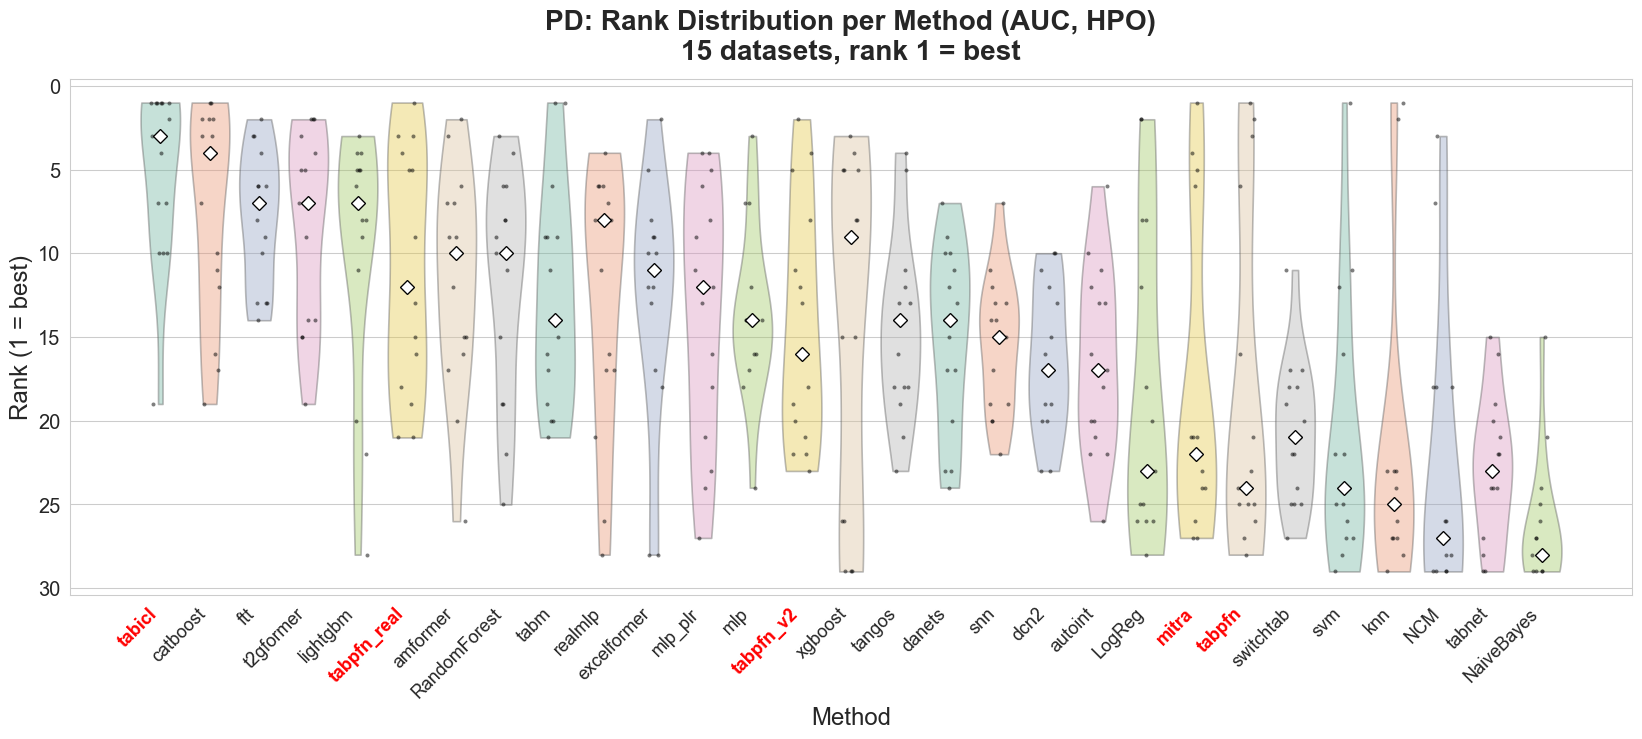

  [2/7] Bootstrap CI plot...
  Saved: pd_rank_bootstrap_ci_hpo.png


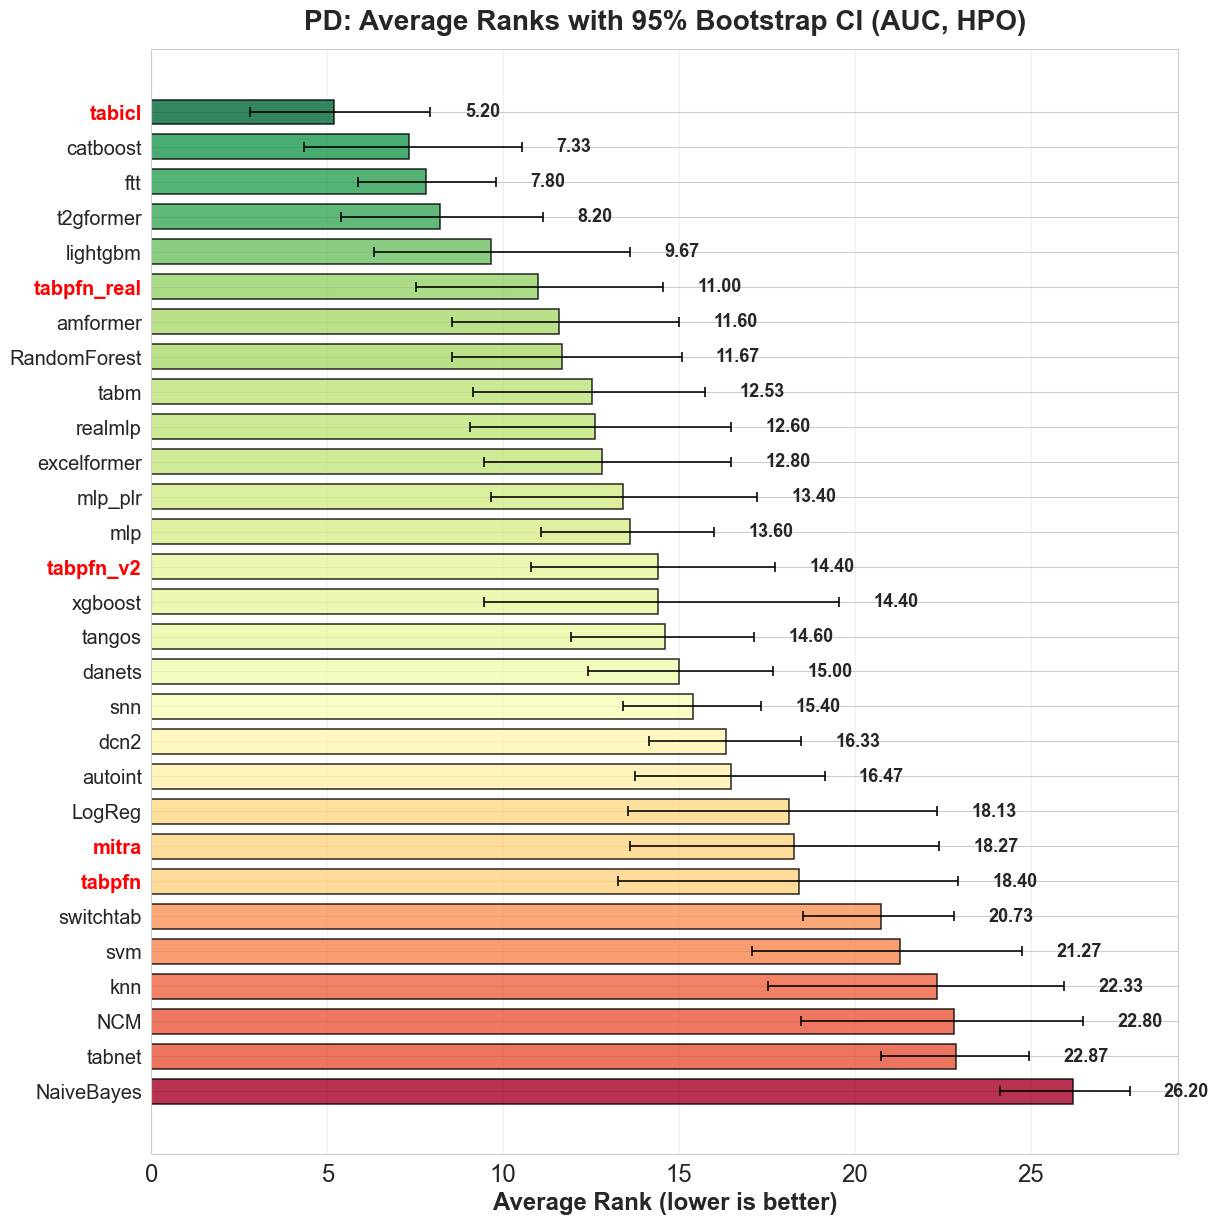

  [3/7] CD diagram (all 29 methods)...
  Saved: pd_cd_all_hpo.png


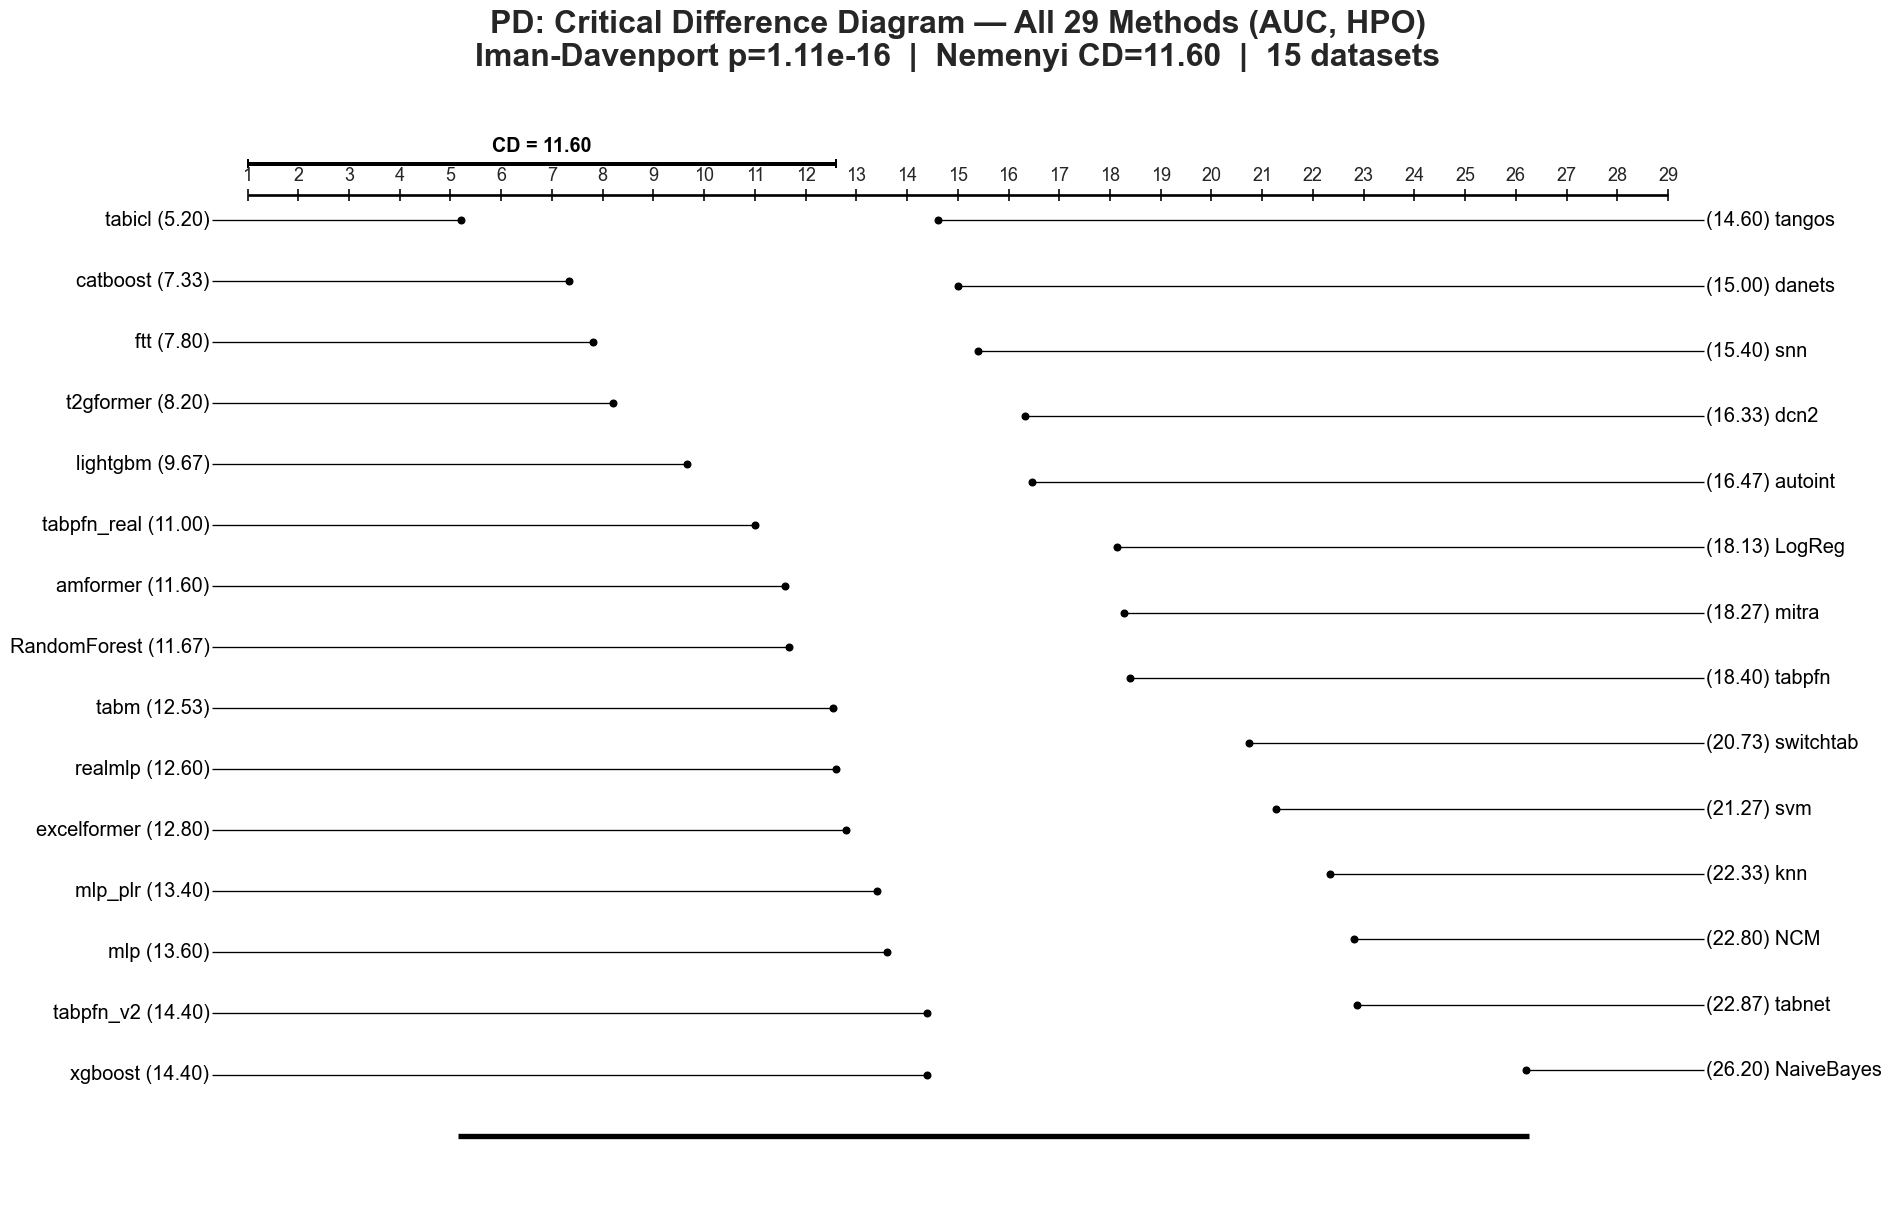

  [4/7] Significance heatmap (p-values)...
  Saved: pd_pval_heatmap_hpo.png


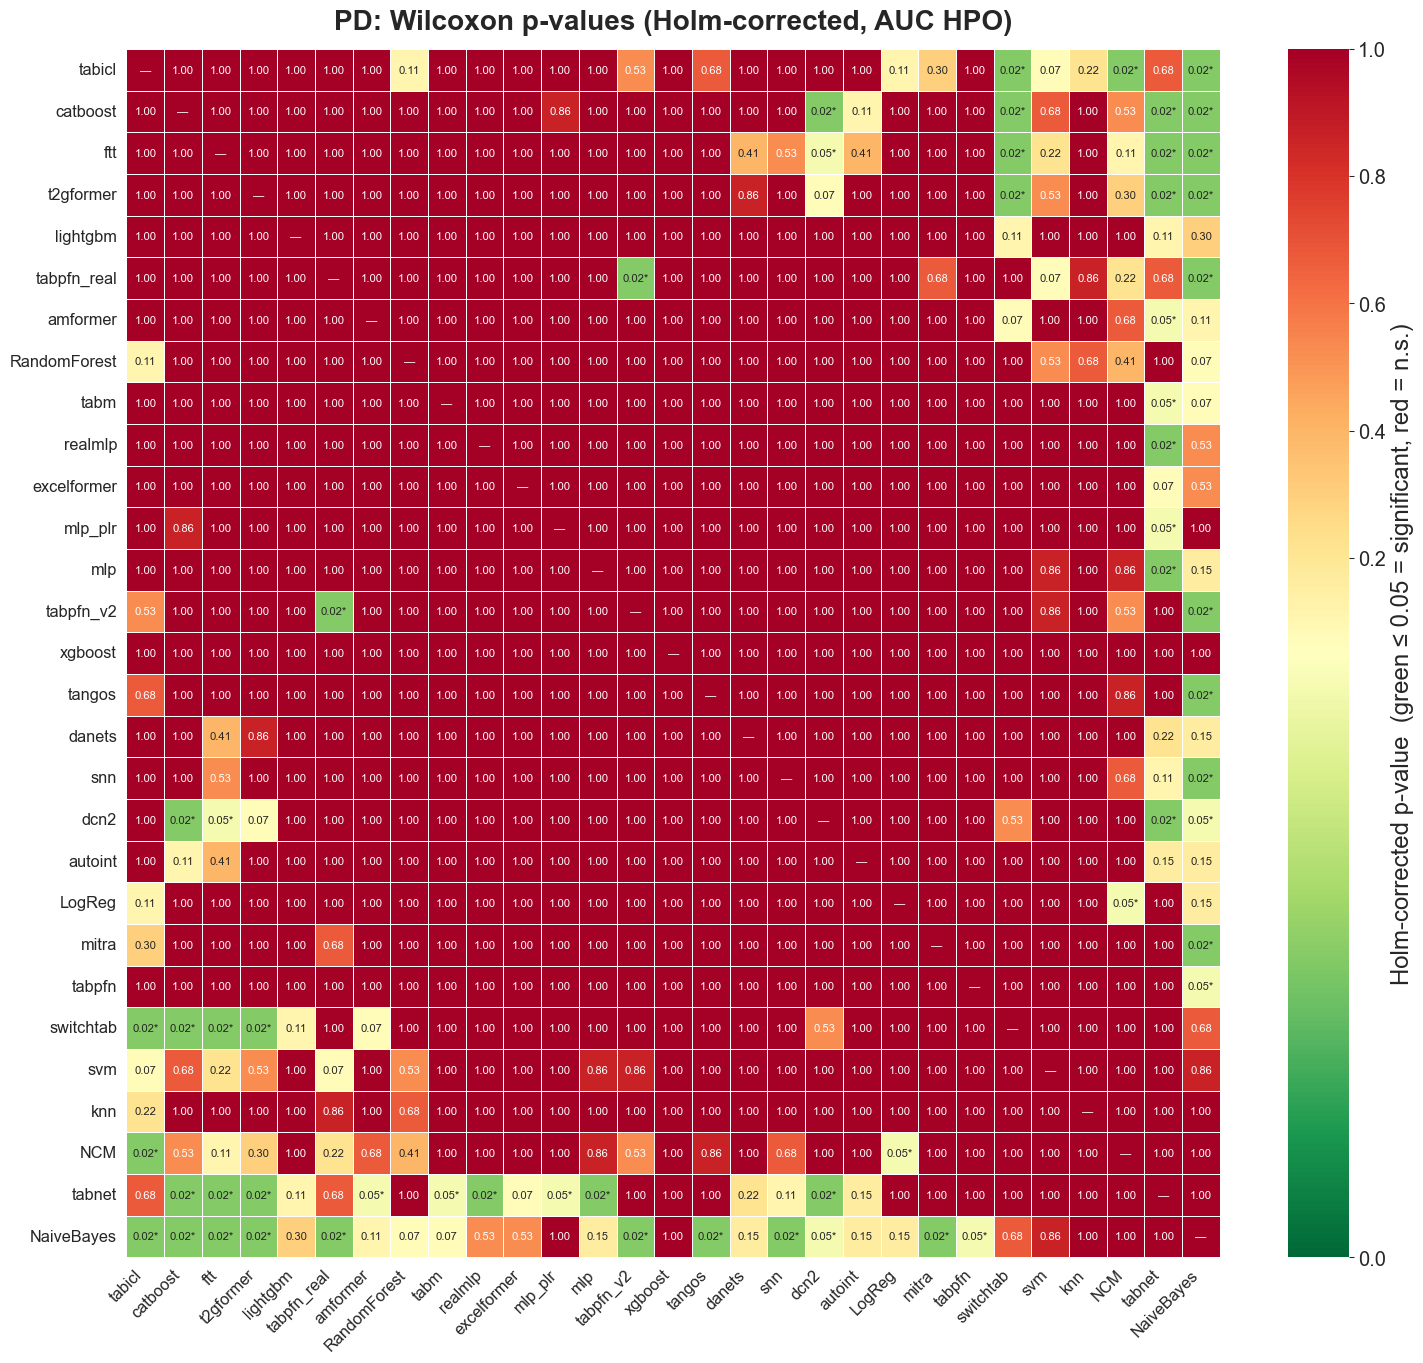

  [5/7] Effect size heatmap (Vargha-Delaney A)...
  Saved: pd_effect_heatmap_hpo.png


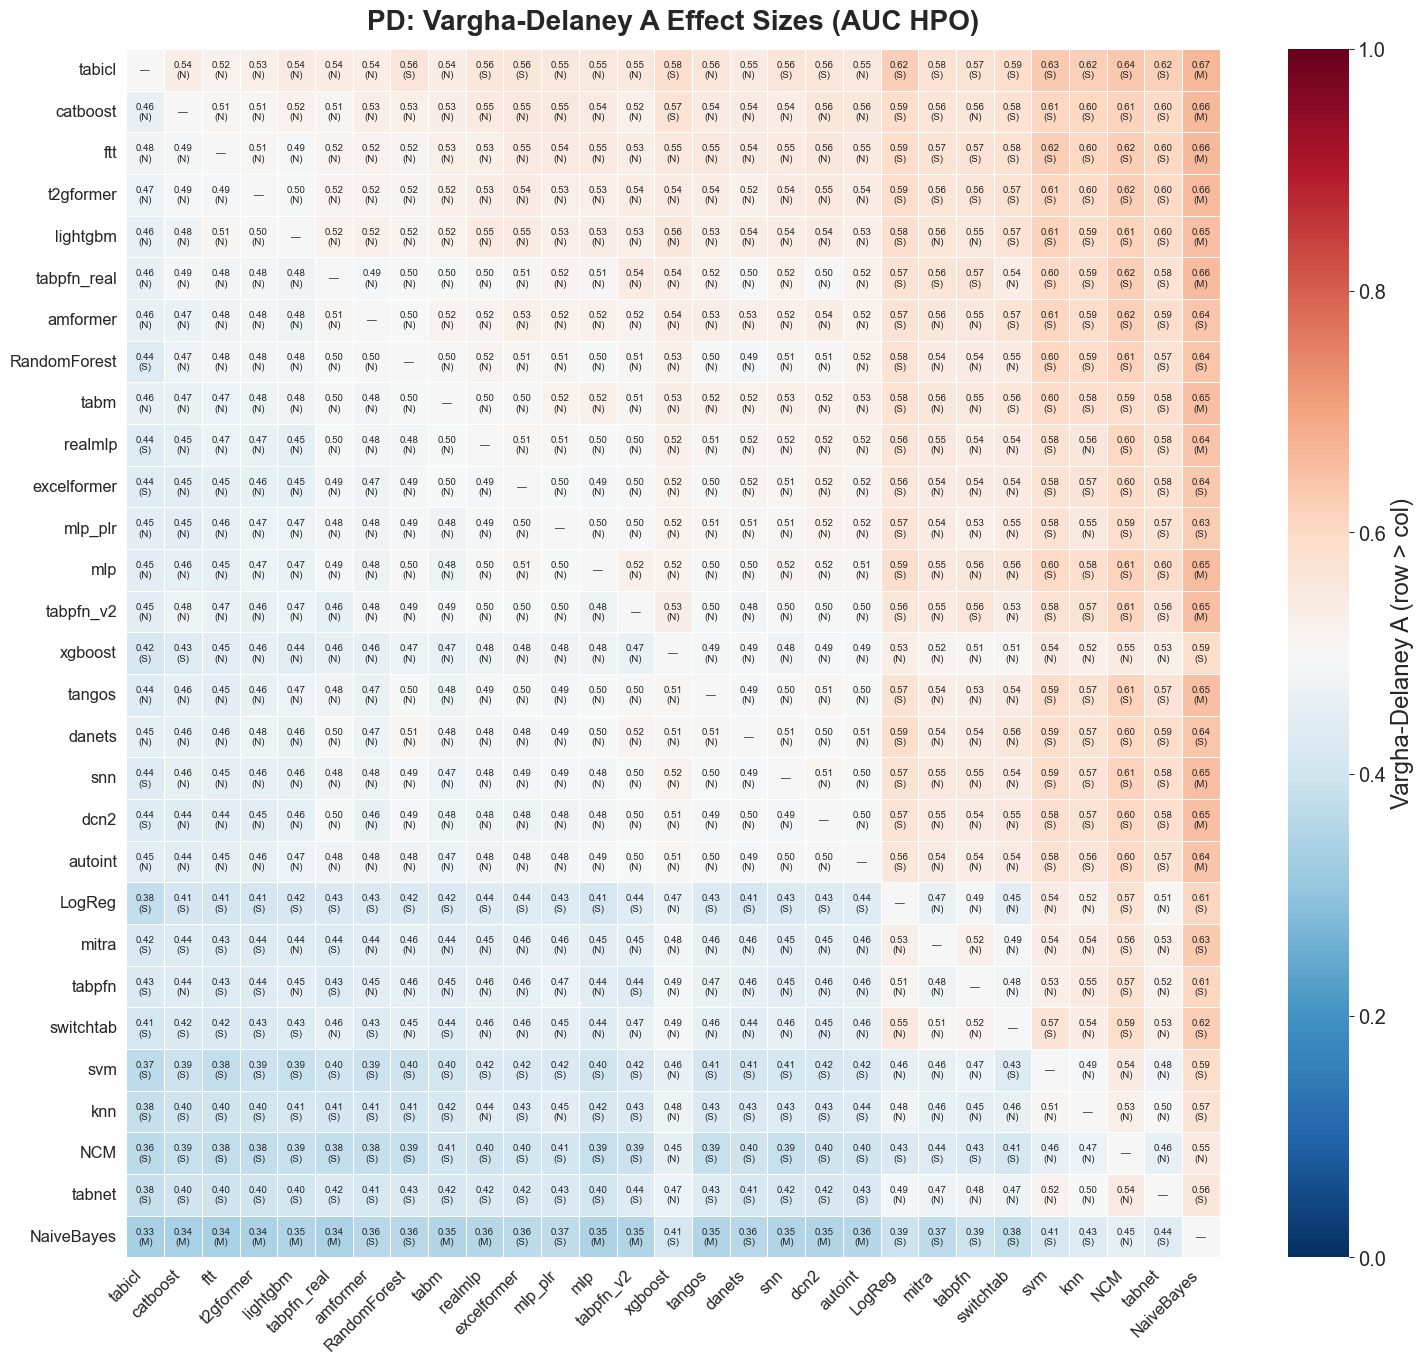

  [6/7] Win/Draw/Loss heatmap...
  Saved: pd_wl_heatmap_hpo.png


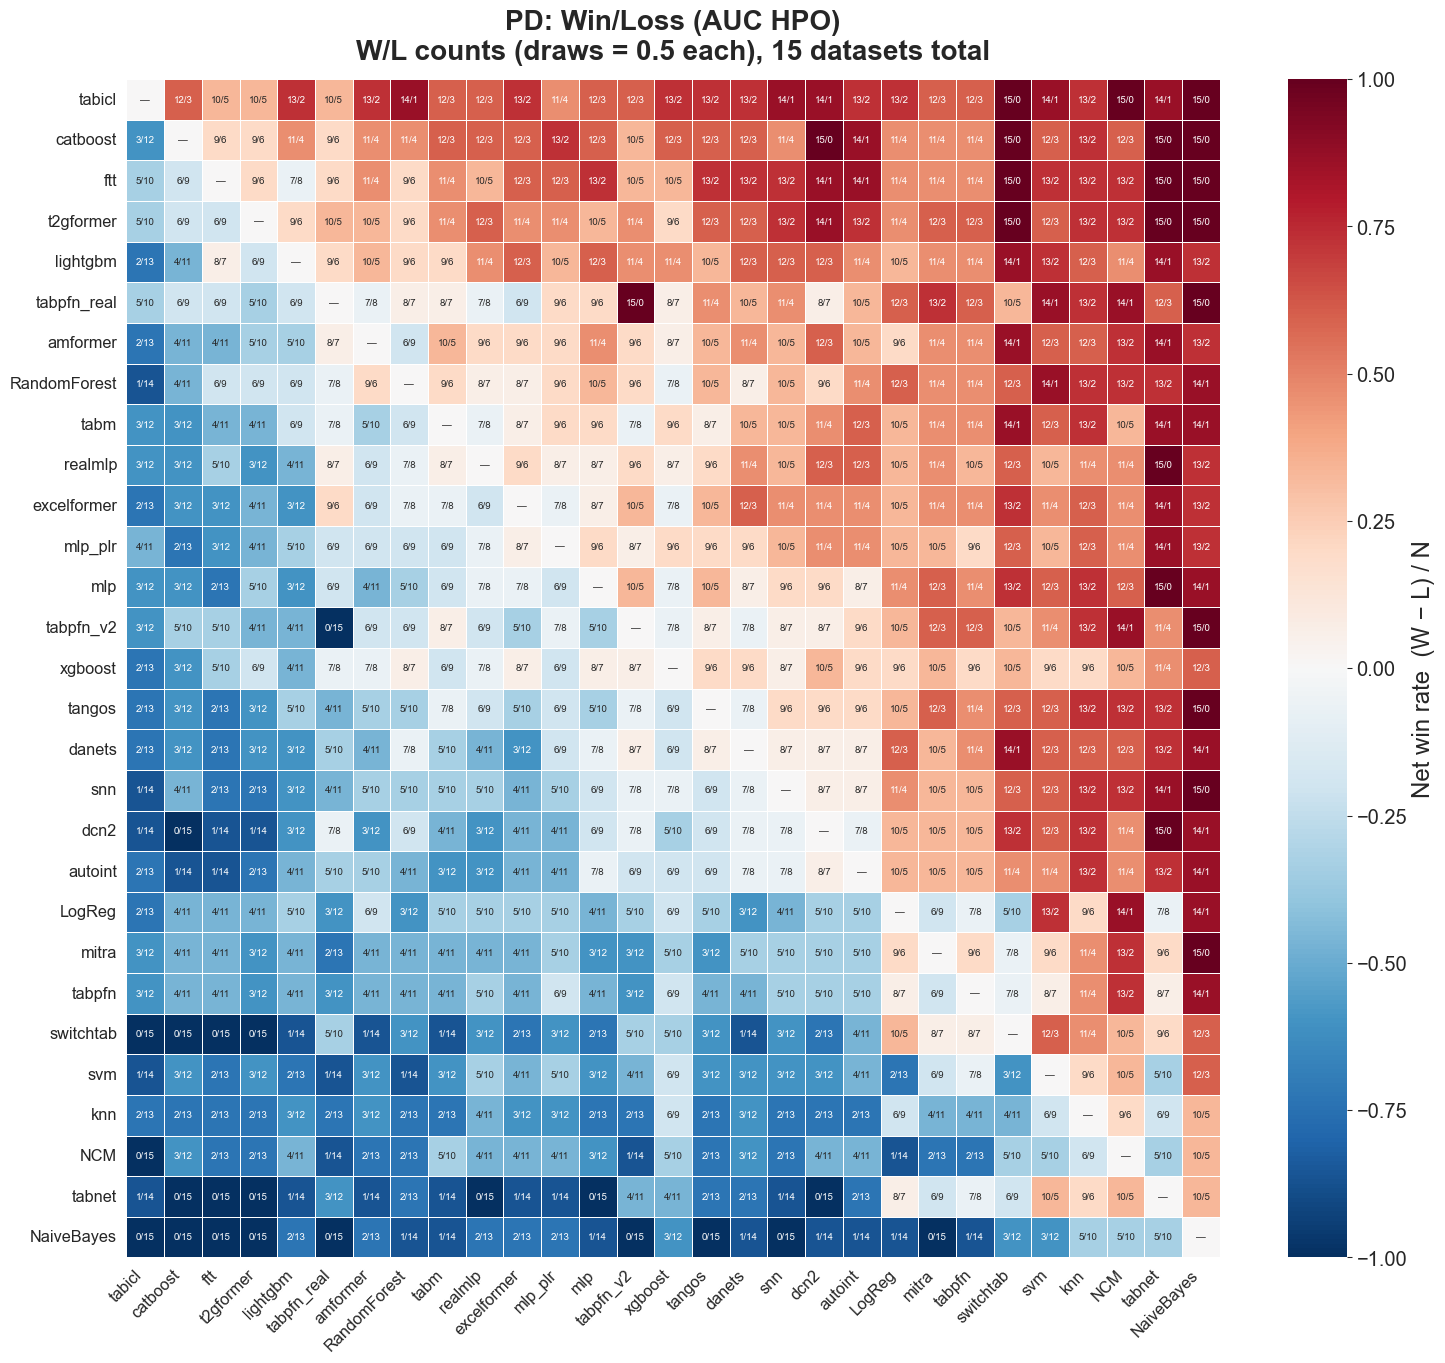

  [7/7] PAMA bar chart...
  Saved: pd_pama_hpo.png


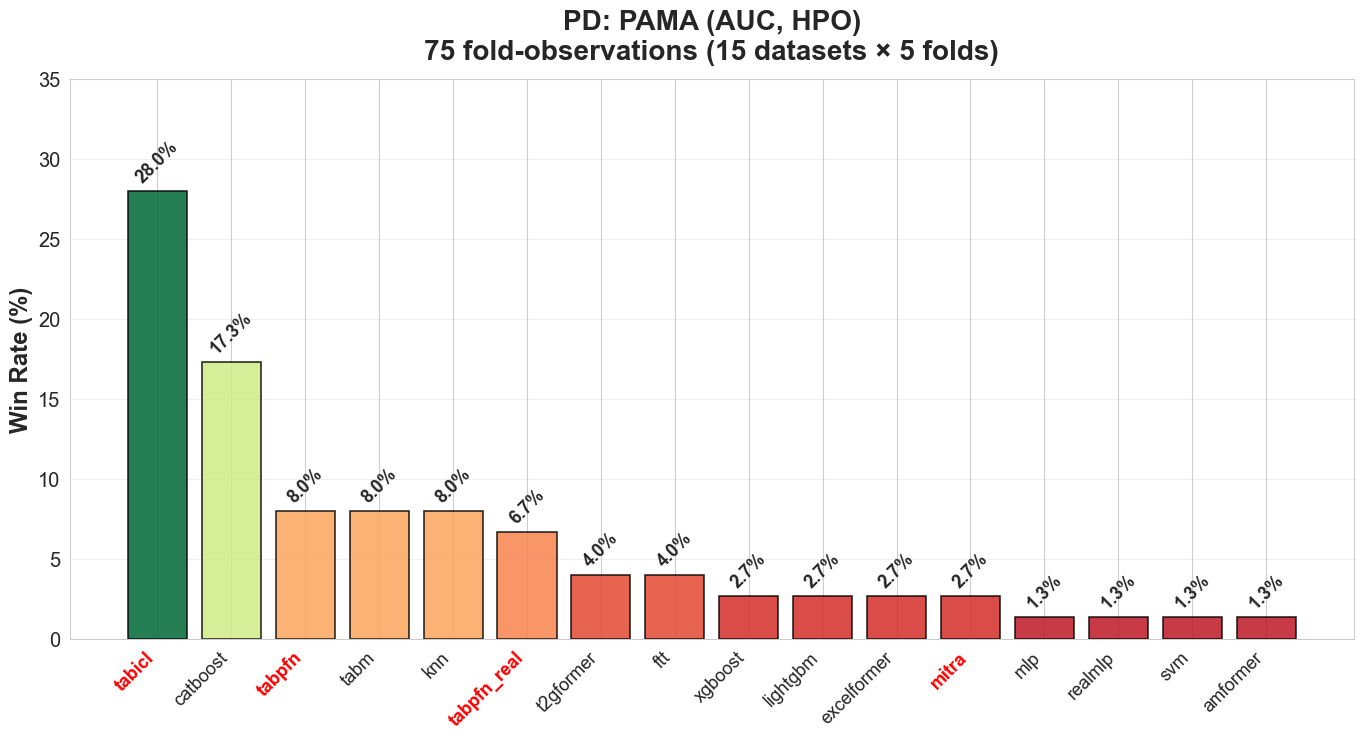


  Pairwise scatter plots (top methods)...
  Saved: pd_scatter_tabicl_vs_catboost_hpo.png


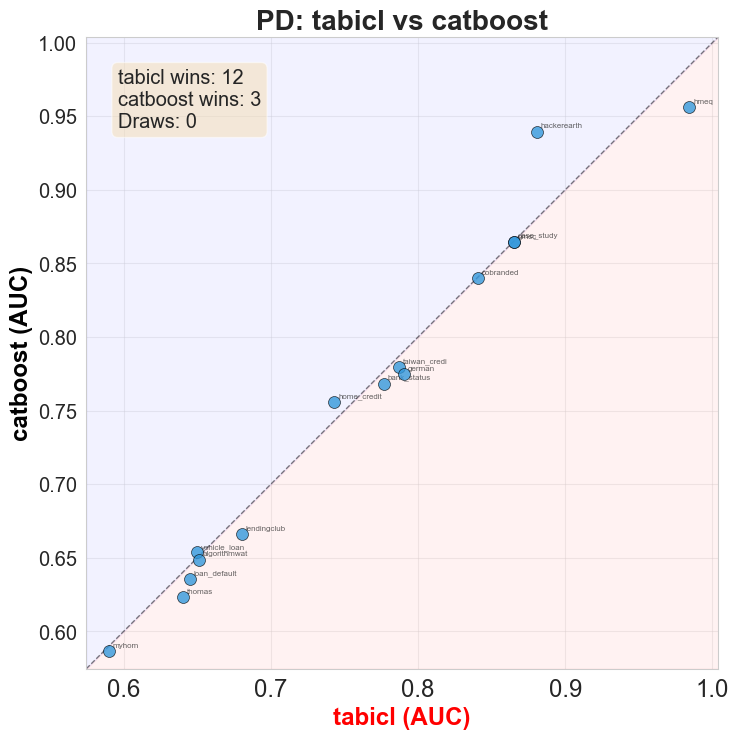

  Saved: pd_scatter_tabicl_vs_ftt_hpo.png


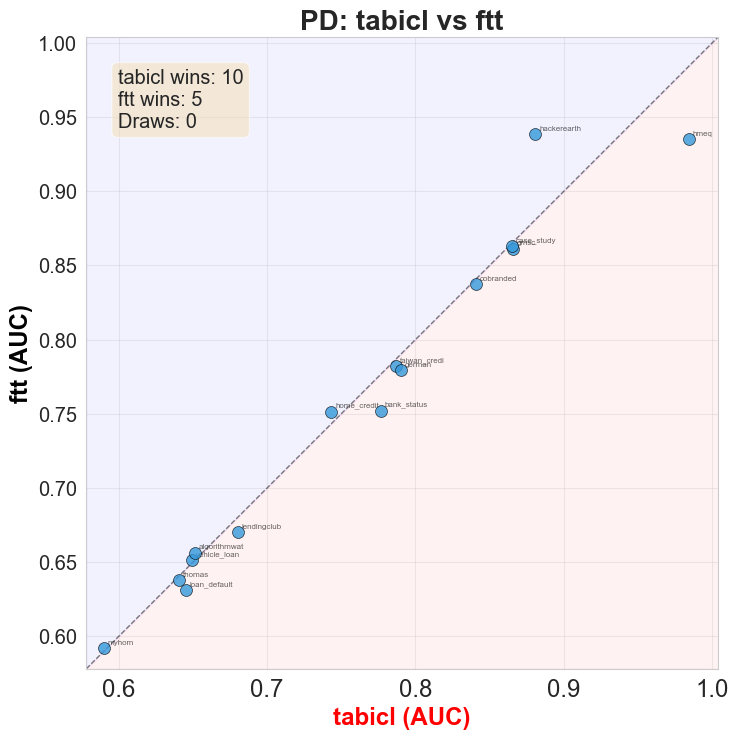

  Saved: pd_scatter_catboost_vs_ftt_hpo.png


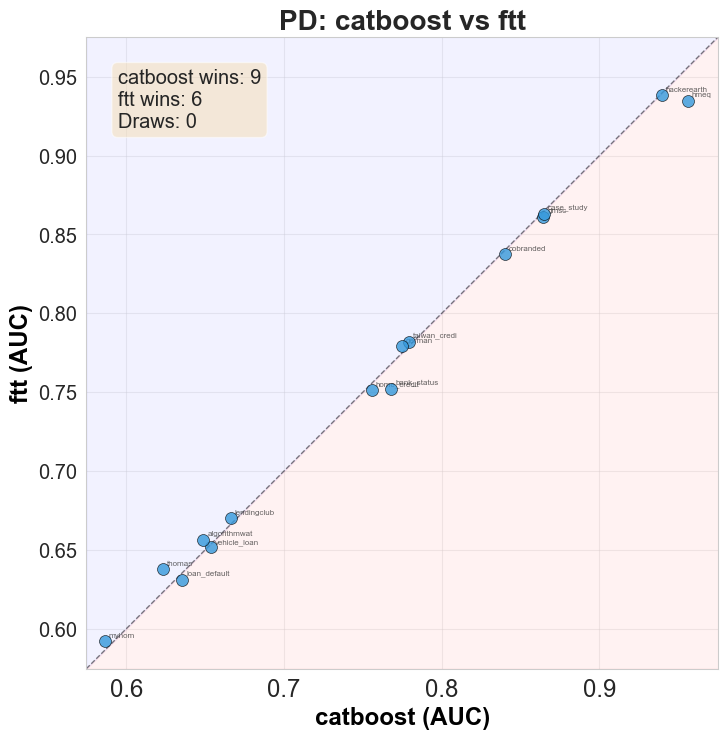


  Combined W/L + significance matrix...
  Saved: pd_wl_significance_hpo.png


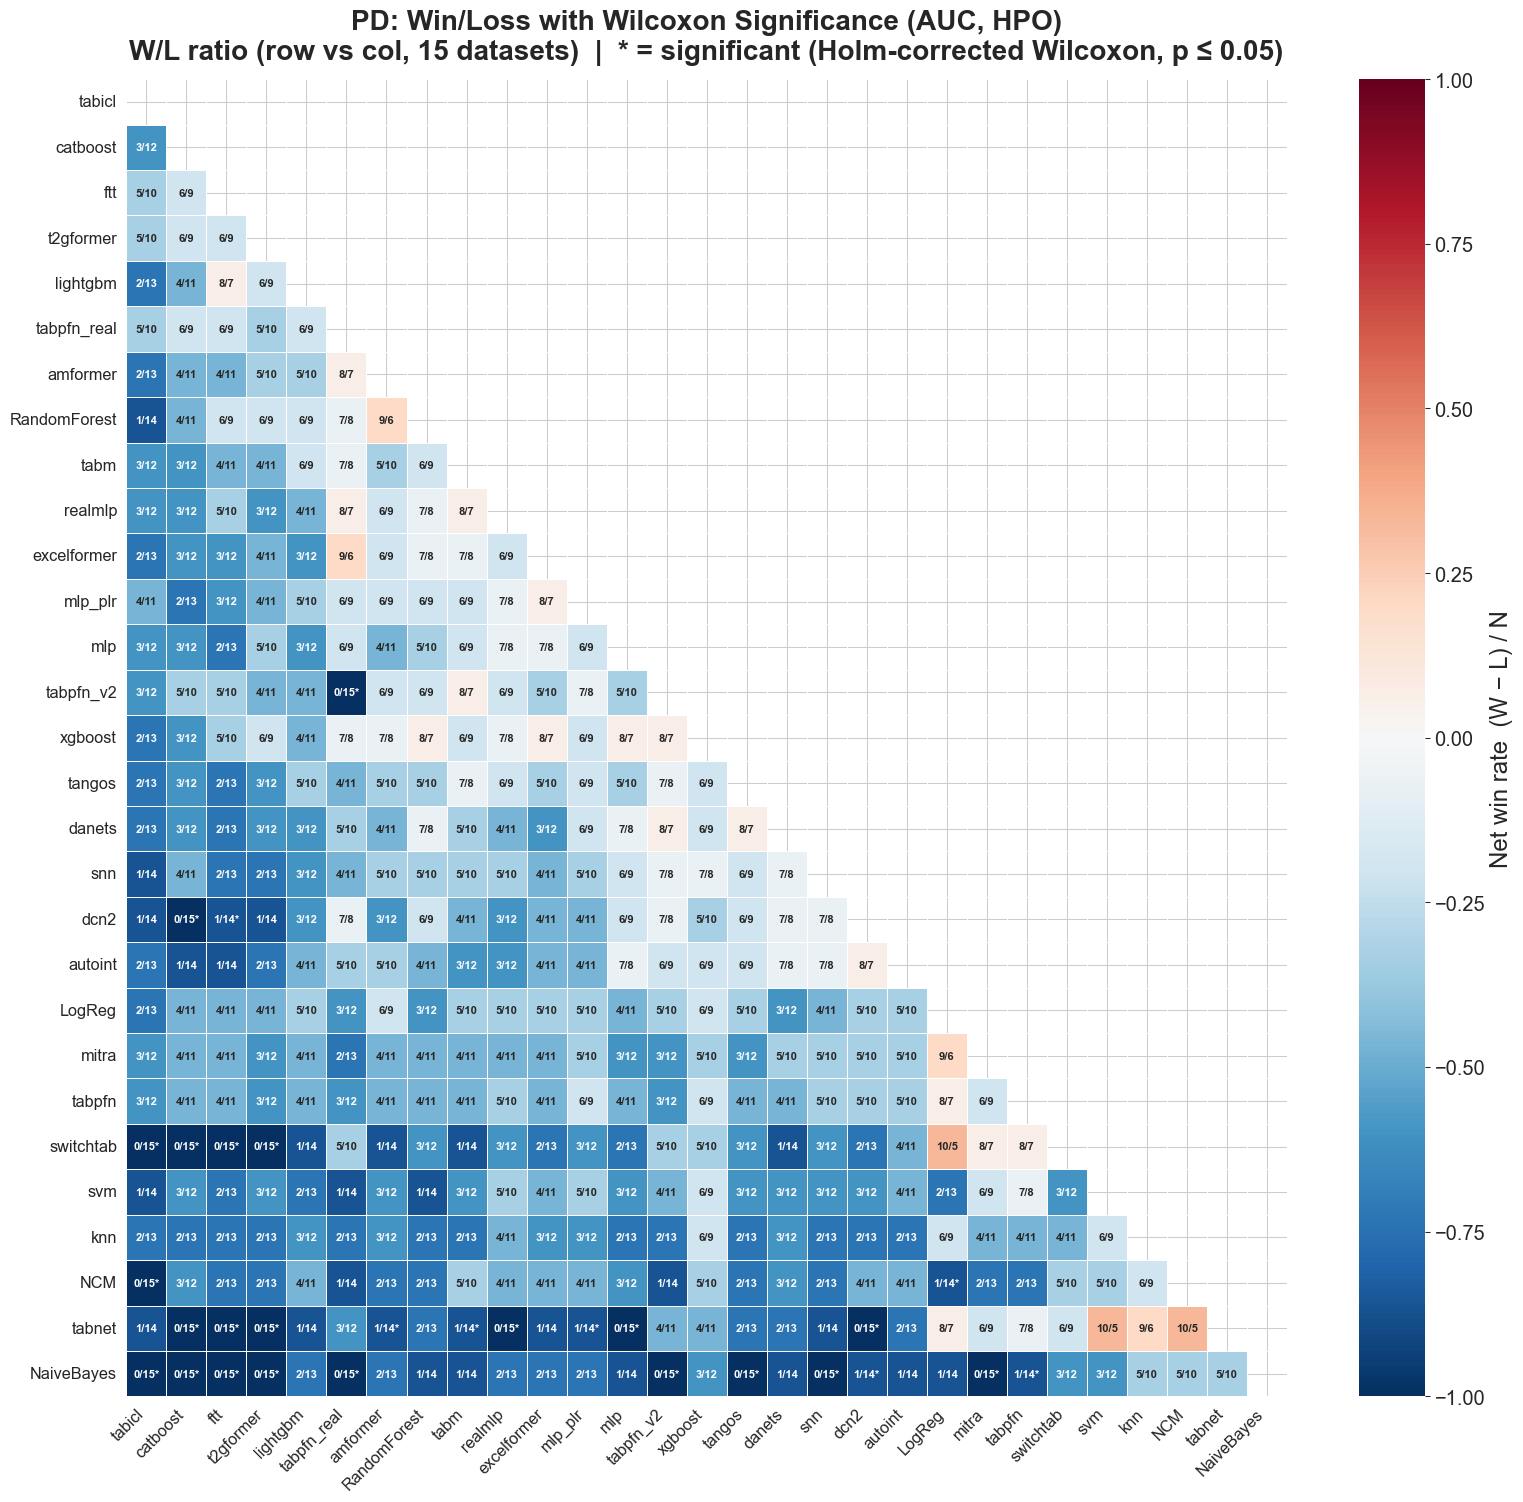


  PD — STATISTICAL SUMMARY
  Metric: AUC (HPO)
  N = 15 datasets, k = 29 methods

  Friedman-Iman-Davenport: p = 1.11e-16  (SIGNIFICANT)
  Nemenyi CD (α=0.05) = 11.603
  Wilcoxon+Holm: 29/406 significant pairs
  PAMA winner: tabicl (28.0% wins)

  Top-5 by average rank:
    1. tabicl                     rank=5.20  [2.80, 7.93] (FM)
    2. catboost                   rank=7.33  [4.33, 10.53]
    3. ftt                        rank=7.80  [5.87, 9.80]
    4. t2gformer                  rank=8.20  [5.40, 11.13]
    5. lightgbm                   rank=9.67  [6.33, 13.60]

  Effect sizes: 0 large, 14 medium, 135 small, 257 negligible


In [41]:
run_full_statistical_analysis(
    pd_raw, 'AUC', 'PD',
    higher_is_better=True,
    foundation_methods=FOUNDATION_METHODS,
    save_dir=FIGURES_DIR
)

---
# Part 2: LGD (Loss Given Default) — R²

**Task:** Regression — predict the fraction of an exposure lost given that a default has occurred.
**Metric:** R² (coefficient of determination). Higher is better. A score of 0 means the model
does no better than predicting the global mean; negative values mean it is worse than that.
**Datasets:** 7 credit risk datasets
**Unit of analysis:** 1 dataset = mean R² across 5 CV folds.

### Why R² for LGD?
R² measures the proportion of variance in LGD that the model explains, relative to a trivial
mean-prediction baseline. It is scale-invariant across datasets. In practice, R² > 0.20 is
considered acceptable and R² > 0.40 is good for LGD (which is inherently noisy).

### ⚠ Caution: low statistical power (N = 7)
With only 7 datasets, all hypothesis tests have limited power.
The Friedman + Wilcoxon tests may fail to reach p < 0.05 even when real differences exist —
this is a *sample size* problem, not evidence that all methods are equal.

**In this section, treat p-values with caution. Prioritise:**
- **Effect sizes (Vargha-Delaney A)**: these describe what actually happened in the data.
- **Win/Loss counts**: direct, interpretable head-to-head evidence.
- **PAMA**: fold-level win rates with more observations (7 × 5 = 35).

A non-significant result here should be read as "inconclusive" rather than "no difference".

## 2.1 Full Statistical Analysis (LGD, R², HPO)

Same pipeline as Part 1, applied to LGD-R².
Remember: with N = 7 datasets, effect sizes and Win/Loss counts carry more weight than p-values.


  LGD — COMPREHENSIVE STATISTICAL ANALYSIS (R2, HPO)

──────────────────────────────────────────────────────────────────────
  A. DESCRIPTIVE STATISTICS
──────────────────────────────────────────────────────────────────────
  Datasets (N) = 7,  Methods (k) = 22
  Metric: R2 (higher is better)
  Unit of analysis: 1 dataset = mean(R2) across 5 CV folds

  Method                        Mean      Std   Median      IQR      Min      Max
  ------------------------- -------- -------- -------- -------- -------- --------
  catboost                    0.4401   0.2170   0.4276   0.3007   0.1655   0.7450
  tabpfn_v2                   0.4455   0.2385   0.3749   0.4107   0.1816   0.7460 *
  realmlp                     0.4203   0.2254   0.3795   0.3064   0.1155   0.7298
  lightgbm                    0.4334   0.2338   0.3970   0.3379   0.1136   0.7421
  excelformer                 0.4132   0.2383   0.3553   0.3340   0.0902   0.7341
  tabm                        0.4206   0.2273   0.3726   0.3363   0.1

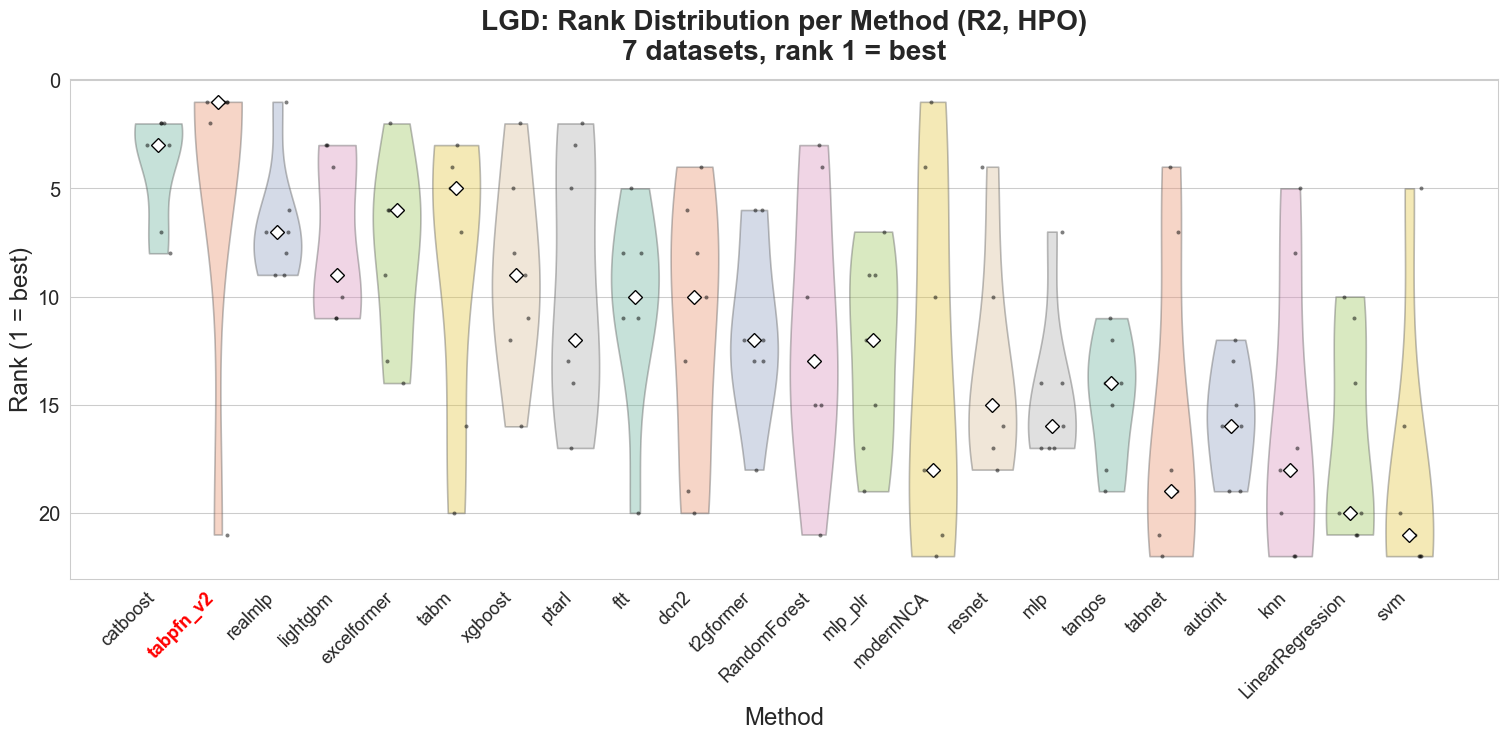

  [2/7] Bootstrap CI plot...
  Saved: lgd_rank_bootstrap_ci_hpo.png


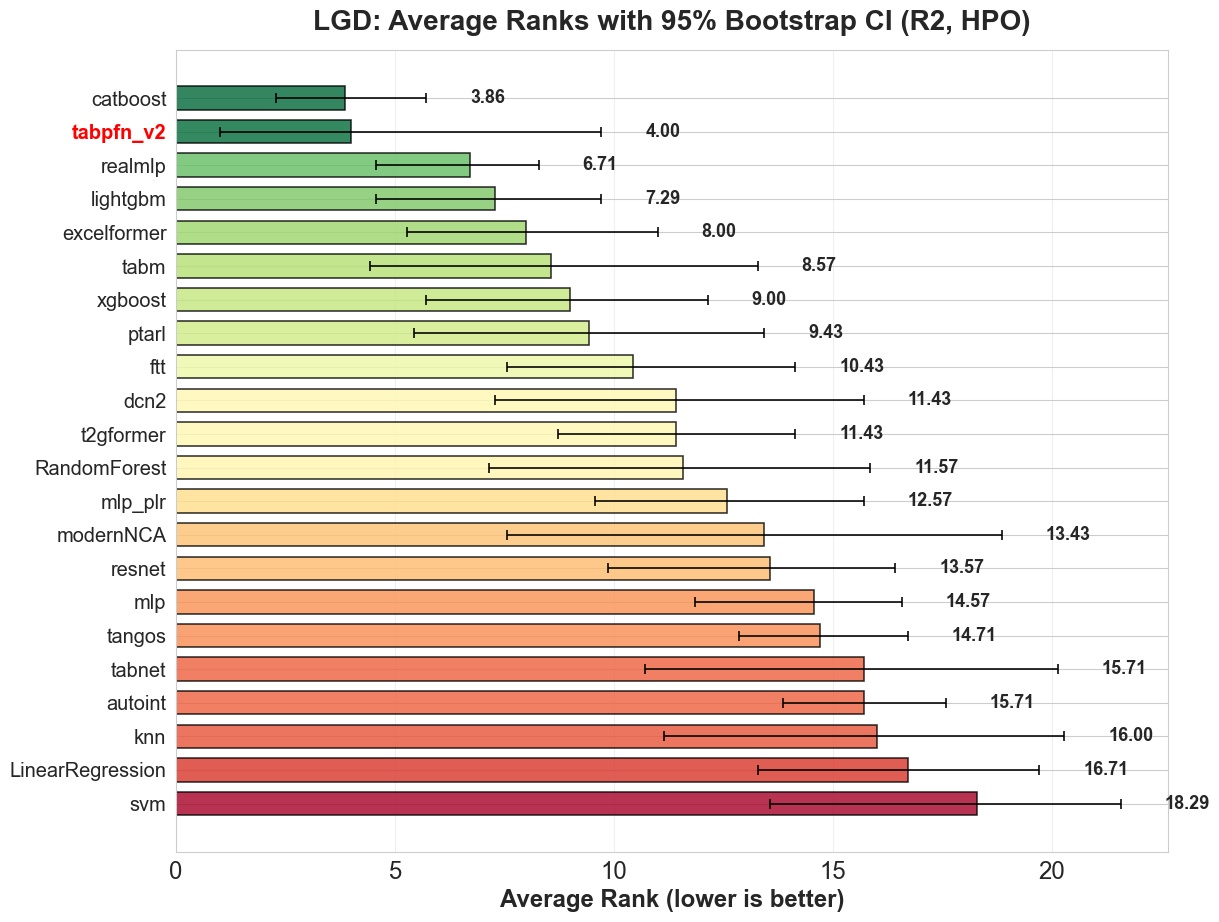

  [3/7] CD diagram (all 22 methods)...
  Saved: lgd_cd_all_hpo.png


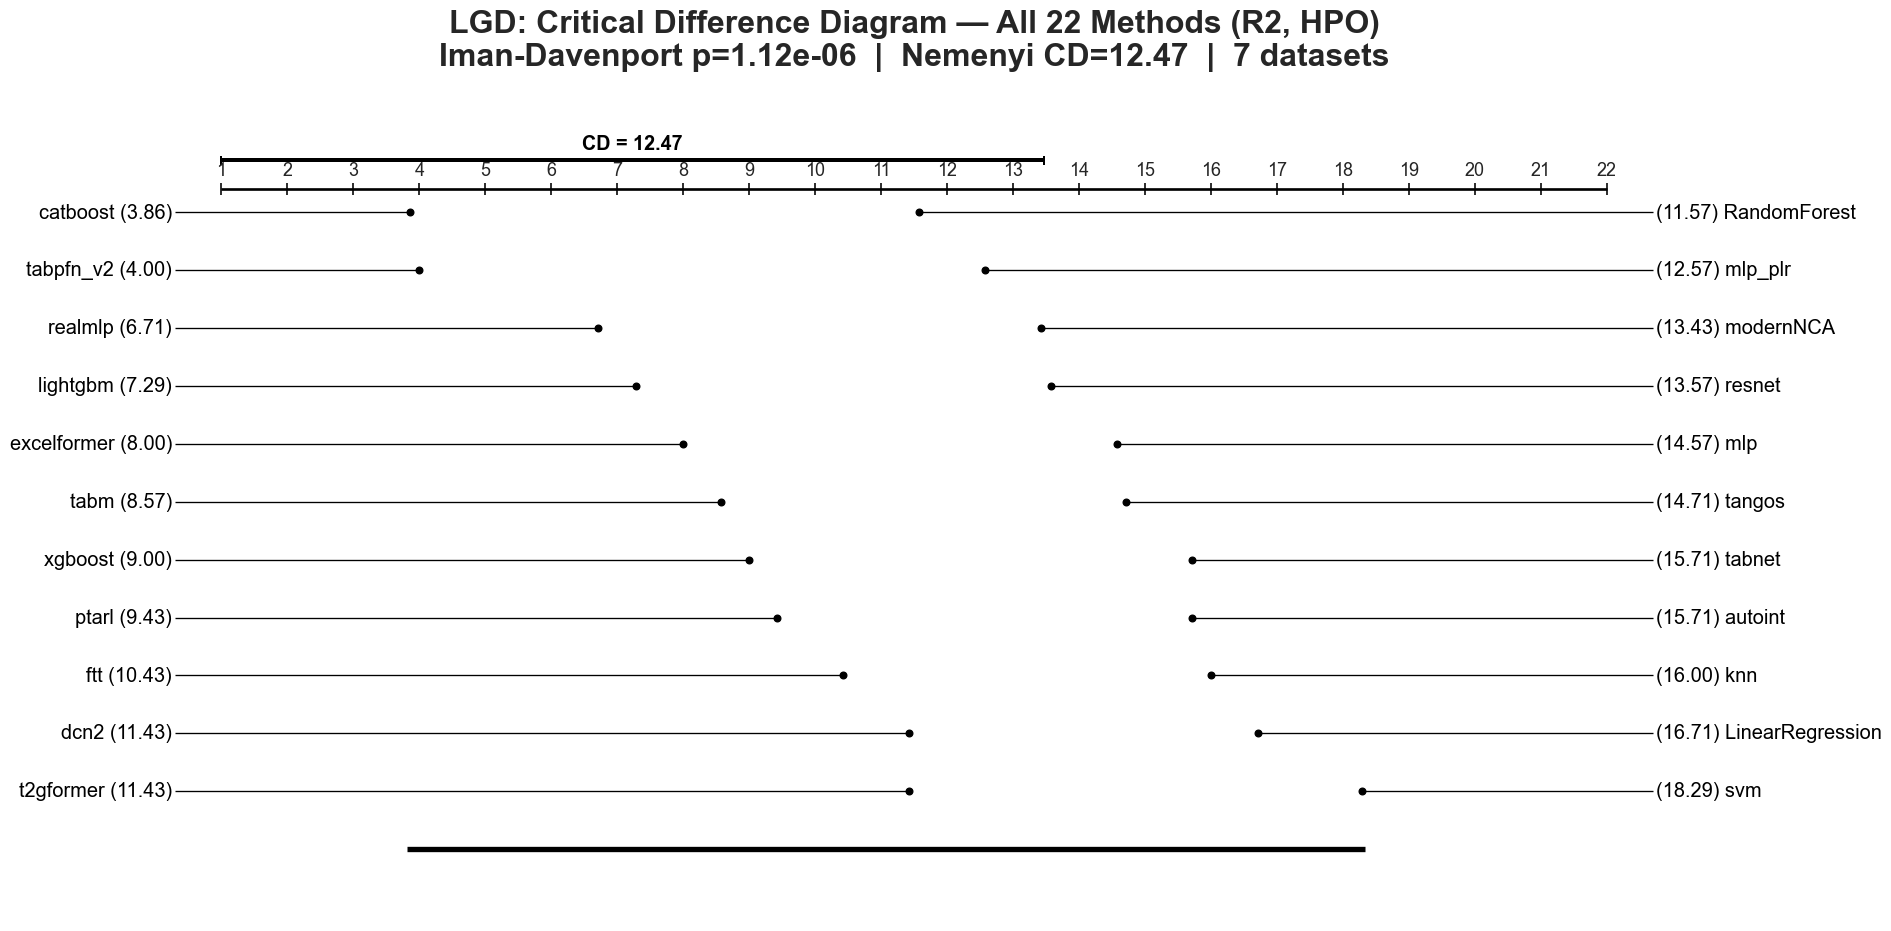

  [4/7] Significance heatmap (p-values)...
  Saved: lgd_pval_heatmap_hpo.png


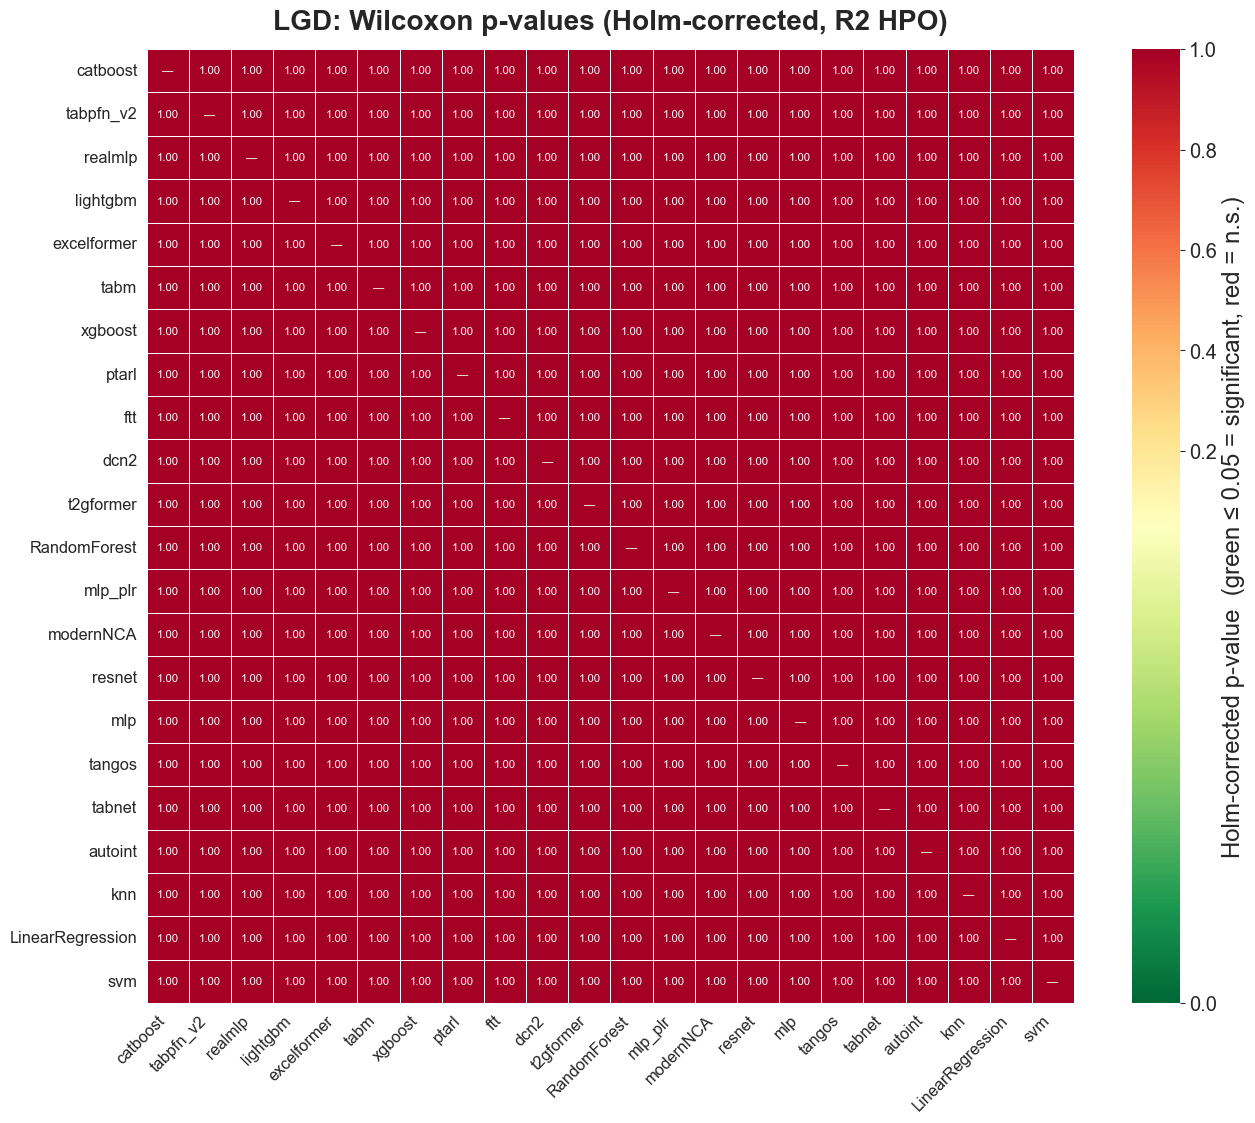

  [5/7] Effect size heatmap (Vargha-Delaney A)...
  Saved: lgd_effect_heatmap_hpo.png


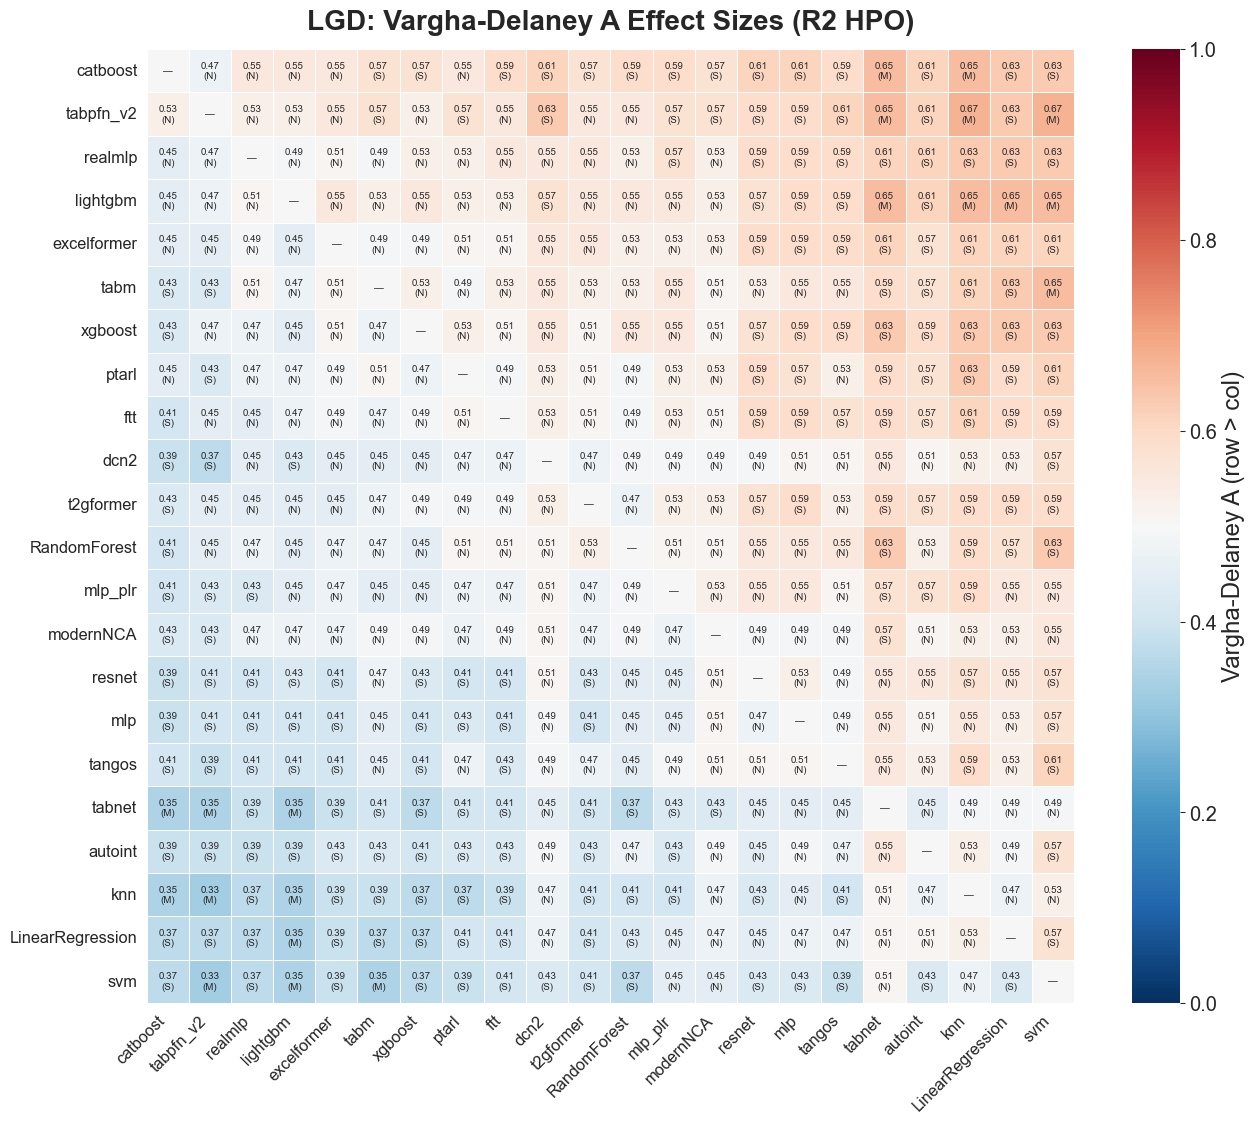

  [6/7] Win/Draw/Loss heatmap...
  Saved: lgd_wl_heatmap_hpo.png


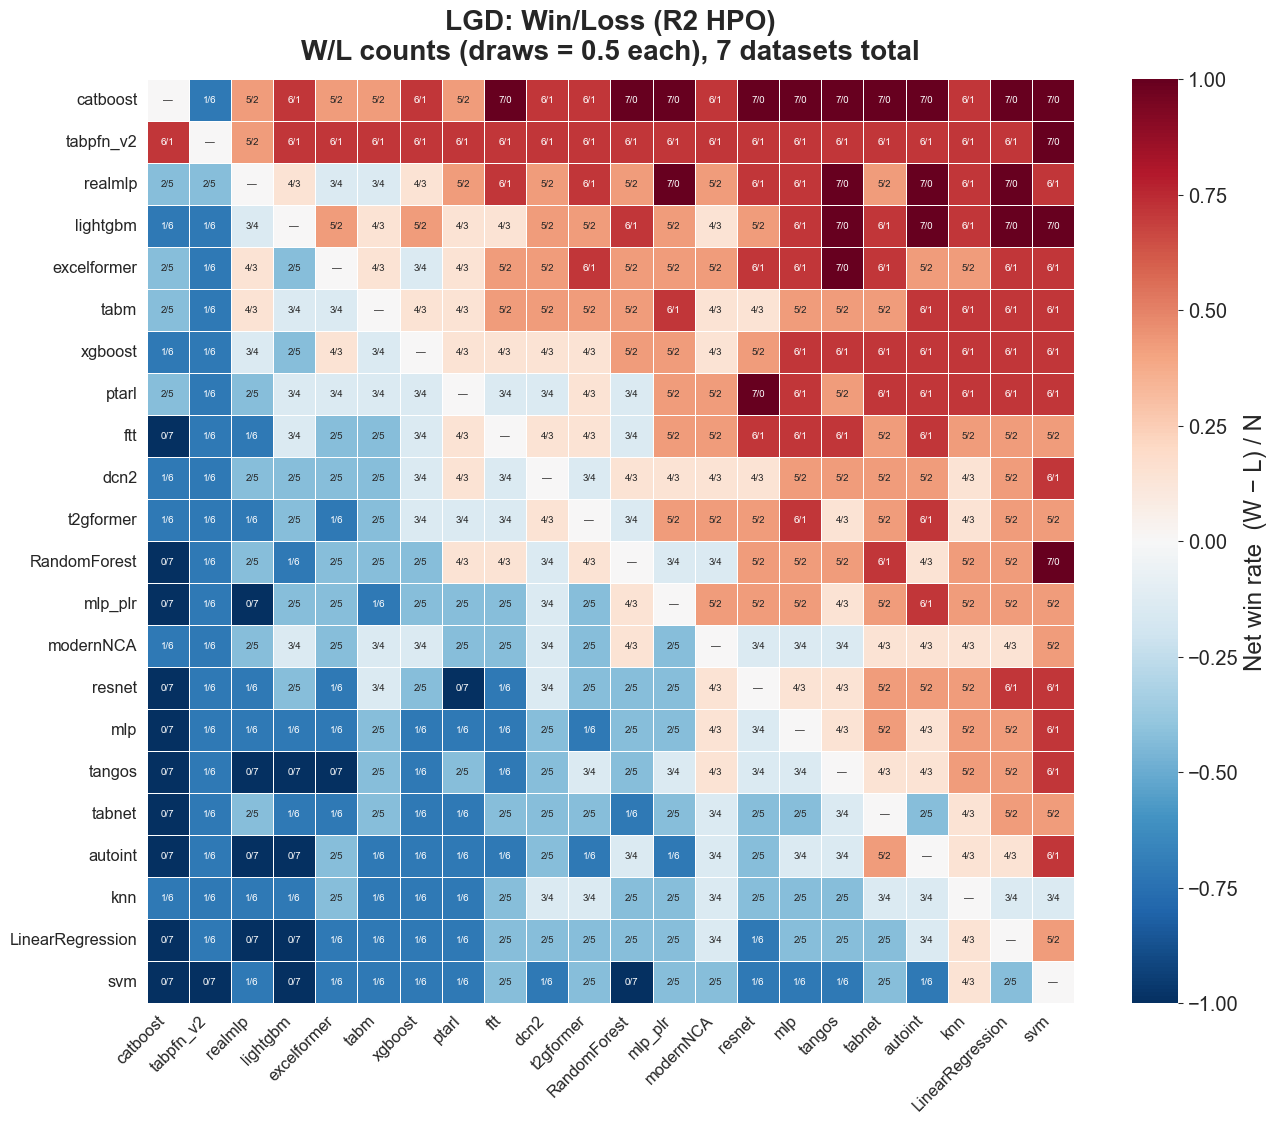

  [7/7] PAMA bar chart...
  Saved: lgd_pama_hpo.png


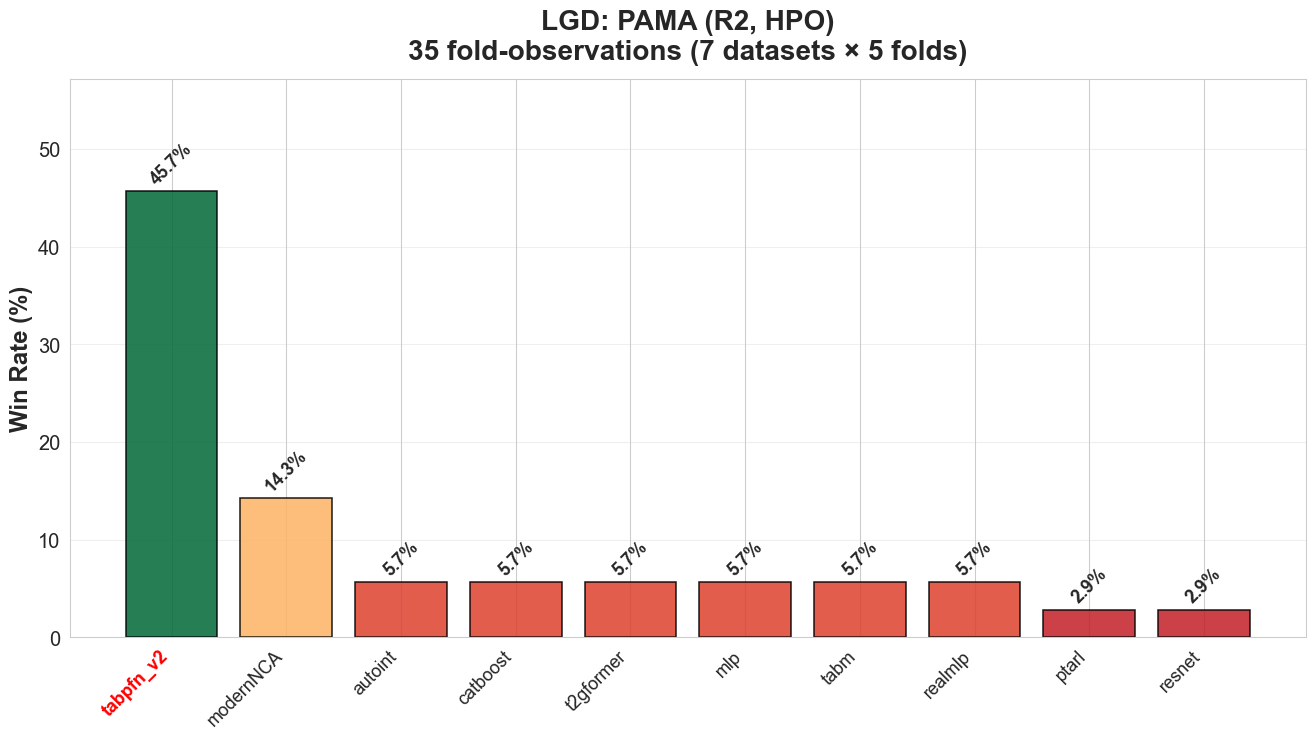


  Pairwise scatter plots (top methods)...
  Saved: lgd_scatter_catboost_vs_tabpfn_v2_hpo.png


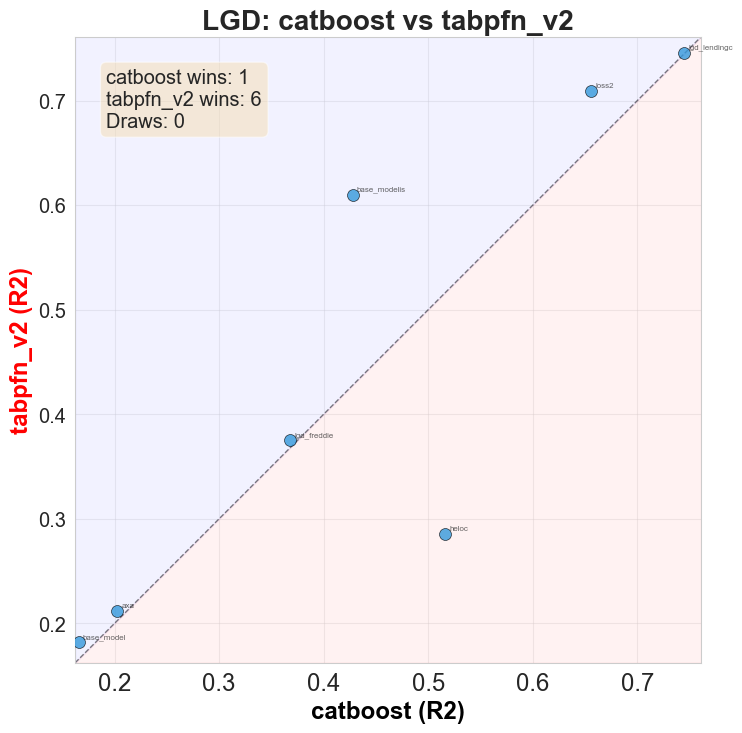

  Saved: lgd_scatter_catboost_vs_realmlp_hpo.png


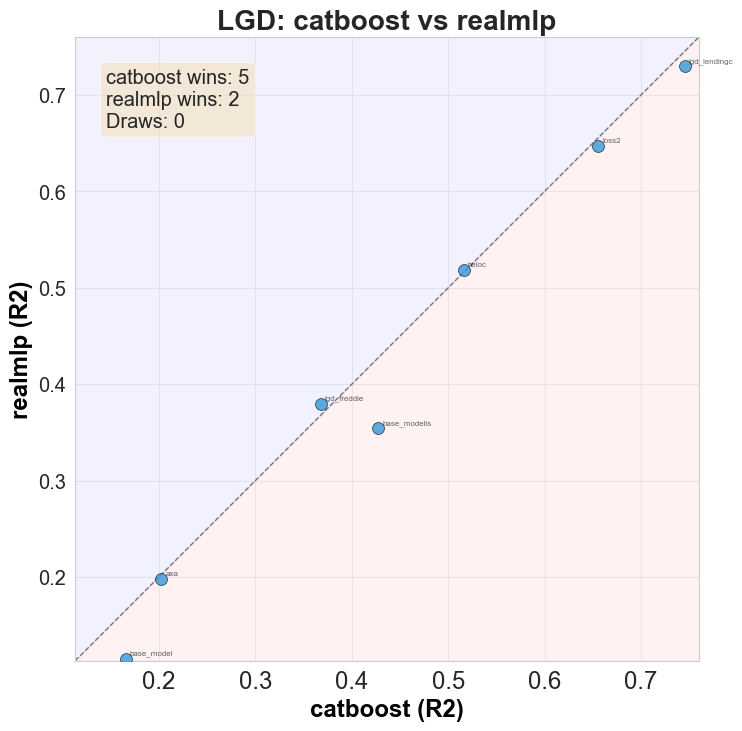

  Saved: lgd_scatter_tabpfn_v2_vs_realmlp_hpo.png


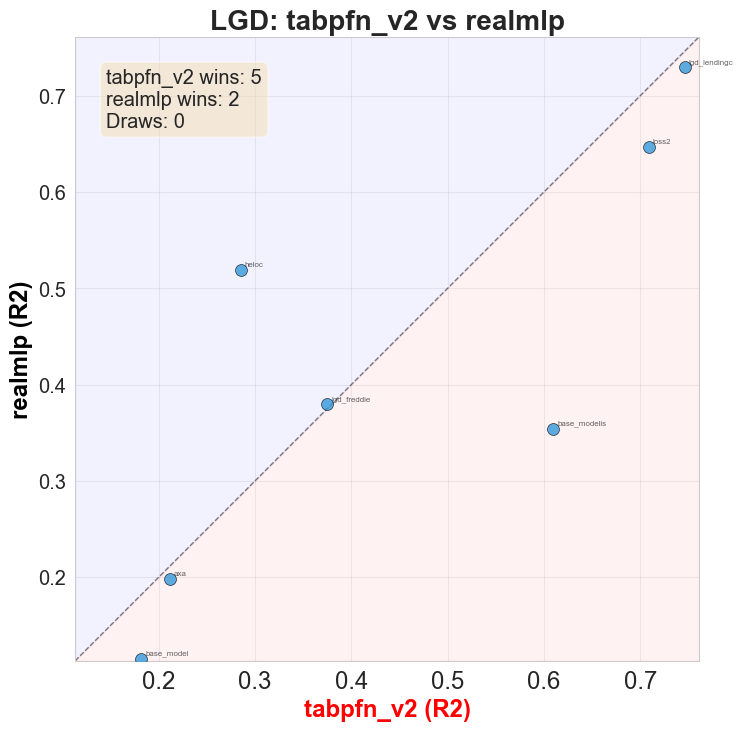


  Combined W/L + significance matrix...
  Saved: lgd_wl_significance_hpo.png


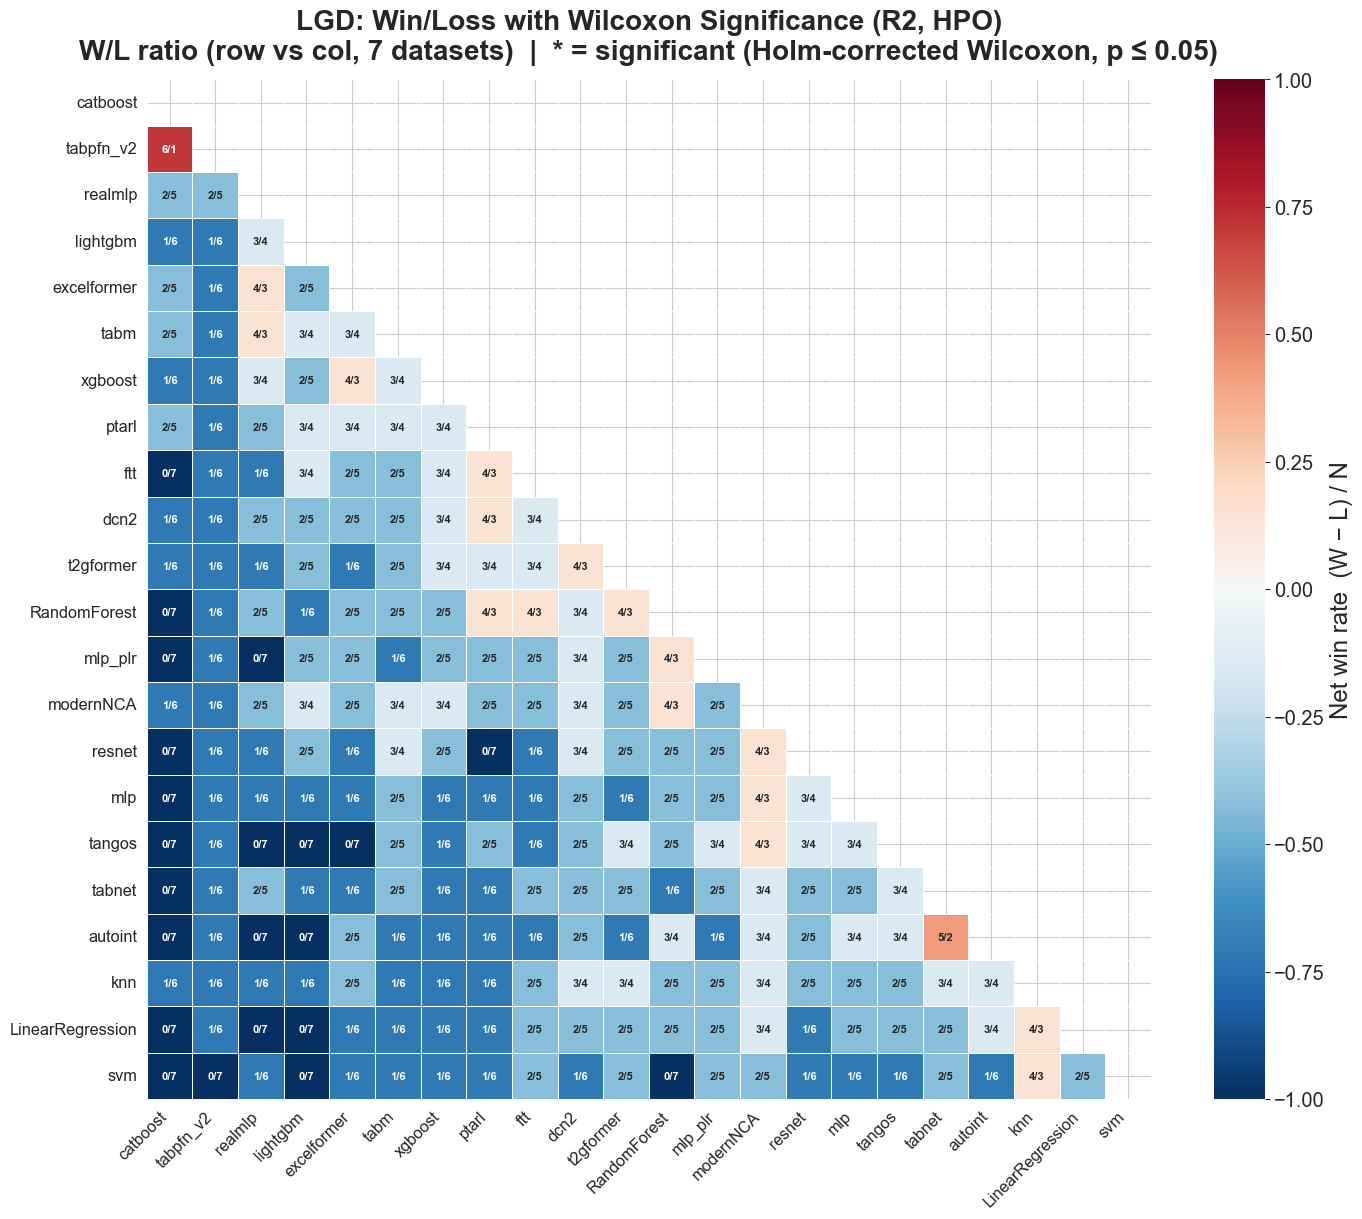


  LGD — STATISTICAL SUMMARY
  Metric: R2 (HPO)
  N = 7 datasets, k = 22 methods

  Friedman-Iman-Davenport: p = 1.12e-06  (SIGNIFICANT)
  Nemenyi CD (α=0.05) = 12.471
  Wilcoxon+Holm: 0/231 significant pairs
  PAMA winner: tabpfn_v2 (45.7% wins)

  Top-5 by average rank:
    1. catboost                   rank=3.86  [2.29, 5.71]
    2. tabpfn_v2                  rank=4.00  [1.00, 9.71] (FM)
    3. realmlp                    rank=6.71  [4.57, 8.29]
    4. lightgbm                   rank=7.29  [4.57, 9.71]
    5. excelformer                rank=8.00  [5.29, 11.00]

  Effect sizes: 0 large, 10 medium, 96 small, 125 negligible


In [42]:
run_full_statistical_analysis(
    lgd_raw, 'R2', 'LGD',
    higher_is_better=True,
    foundation_methods=FOUNDATION_METHODS,
    save_dir=FIGURES_DIR
)

---
# Part 3: Summary & Interpretation Guide

## How to read each output

### B — Friedman + Iman-Davenport (the gate test)
- **p < 0.05** → Real differences exist somewhere. Post-hoc tests are licensed.
- **p ≥ 0.05** → Methods are statistically indistinguishable at this sample size.
  Post-hoc results technically exist in the output but should not be used for inference.

### C — Critical Difference diagram
- **Methods connected by a thick bar** are statistically indistinguishable from each other (α = 0.05).
  Being in the same group does NOT mean they perform equally — only that the data is insufficient
  to separate them at this N.
- **Methods NOT connected** to each other are significantly different.
- **Smaller k diagrams (top 10, top 5)** have smaller CDs, giving finer resolution among
  the competitive methods. Use these to distinguish the top performers.

### D — Significance heatmap (Wilcoxon + Holm)
- **Green cell (p < 0.05)** → row and column method are significantly different.
  Check the average rank table to see which one is better.
- **Red cell (p ≥ 0.05)** → not distinguishable at this sample size.
- Stars: `*` p < 0.05 · `**` p < 0.01 · `***` p < 0.001

### E — Effect size heatmap (Vargha-Delaney A)
- **Cell [row, col] = 0.70** → the row method scores higher than the column method on 70% of datasets.
  This is a *large* effect (well above the 0.71 threshold for large).
- **Cell = 0.50** → no effect whatsoever — the methods are equivalent across datasets.
- **Cell = 0.30** → the *column* method is actually better (the row method wins only 30% of the time).
- Effect labels: **N** = negligible (|A−0.5| < 0.06) · **S** = small · **M** = medium · **L** = large (> 0.21)
- **Key insight**: always read effect sizes alongside p-values. A statistically *significant*
  pair with A = 0.52 (label N) has no practical relevance. A statistically *non-significant*
  pair with A = 0.75 (label L) is practically important but underpowered.

### F — Win/Loss heatmap
- **Cell [row, col] = "11/4"** → the row method scored higher on 11 out of N datasets
  (draws each contributed 0.5 to both sides, so W + L = N always).
- **Blue cell** → row method wins more than it loses.
- **Red cell** → row method loses more than it wins.
- The symmetric cell [col, row] shows "4/11" — the complementary perspective.

### G — PAMA bar chart
- **Tall bar** → this method is the outright best performer on a high fraction of (dataset, fold) pairs.
- **Zero PAMA** → the method never achieves the top score outright (though it may still rank 2nd).
- PAMA is descriptive, not a hypothesis test. It answers the practical question:
  "If I had to pick one method for a new credit dataset, which one wins most often?"

### H — Bootstrap CI bars
- **Narrow CI** → stable ranking; the order holds regardless of which specific datasets are included.
- **Wide CI** → unstable ranking; adding or removing a few datasets could substantially
  change the method's position.
- **Overlapping CIs** between two methods → their true ranks could plausibly be equal.
  This is a softer form of the Wilcoxon test result.

---

## Design Choices & Justifications

| Choice | Justification |
|--------|--------------|
| Dataset-level averaging for hypothesis tests | Folds within a dataset are correlated; treating them as independent inflates N (Demsar 2006) |
| Fold-level for PAMA | PAMA is a descriptive count, not a hypothesis test; finer granularity is acceptable |
| Holm > Bonferroni | Uniformly more powerful while controlling the same family-wise error rate (Garcia & Herrera 2008) |
| Wilcoxon > t-test | No normality assumption required for bounded metrics like AUC |
| Nemenyi CD for visualisation + Wilcoxon for inference | CD diagram gives intuitive groupings; Wilcoxon+Holm gives the statistically powered decisions |
| Effect sizes always reported | p-values alone are insufficient; effect sizes quantify practical relevance |
| Bootstrap CIs | Quantify rank uncertainty without distributional assumptions |
| 10,000 bootstrap resamples | Enough for stable 2.5th/97.5th percentile estimates |

---

## Visualizations Generated (per task)

| # | File suffix | What it shows |
|---|-------------|---------------|
| 1 | `_rank_violin_hpo` | Spread of per-dataset ranks per method |
| 2 | `_rank_bootstrap_ci_hpo` | Average rank ± 95% bootstrap CI |
| 3 | `_cd_all_hpo` | CD diagram — all methods |
| 4 | `_cd_top10_hpo` | CD diagram — top 10 methods |
| 5 | `_cd_top5_hpo` | CD diagram — top 5 methods |
| 6 | `_pval_heatmap_hpo` | Wilcoxon p-values (Holm-corrected) |
| 7 | `_effect_heatmap_hpo` | Vargha-Delaney A effect sizes |
| 8 | `_wl_heatmap_hpo` | Win/Loss heatmap (draws = 0.5 each) |
| 9 | `_pama_hpo` | PAMA fold-level win rates |
| 10+ | `_scatter_*_hpo` | Pairwise scatter plots for top methods |